# Advanced Machine Learning 2026/2027
## Projeto: Modeling Recovery after Lower-Limb Musculoskeletal Injury
### M0 — Exploratory Data Analysis

**Grupo:** 14

| Número | Nome |
|---|---|
| fc68043 | David Belykh |
| fc68080 | Matilde Quitério |
| fc68091 | Ramyad Raadi |

### Declaração sobre o uso de IA generativa
Foram utilizadas ferramentas de IA generativa (Claude, Anthropic) neste milestone como apoio à **geração de código** (pandas/matplotlib/seaborn), à **análise exploratória dos dados** e à **melhoria da redação** do texto. Todo o código foi executado e os resultados, interpretações e conclusões foram revistos, verificados e validados pelos elementos do grupo, que se responsabilizam integralmente pelo conteúdo submetido.

## 0. Configuração e carregamento dos dados

Seguindo o enunciado, cada linha de `rehabilitation.csv` (par doente-semana) é tratada como uma **observação independente**, exceto quando analisamos explicitamente a evolução temporal ou trajetórias individuais. O ficheiro `patients.csv` é usado para os resumos das características estáticas (baseline).

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

import os

# Função para procurar os ficheiros automaticamente (evita erros de caminhos de pastas)
def find_file(filename, search_path="."):
    for root, dirs, files in os.walk(search_path):
        if filename in files:
            return os.path.join(root, filename)
    raise FileNotFoundError(f"Não foi possível encontrar o ficheiro '{filename}'.")

patients = pd.read_csv(find_file("patients.csv"))
rehab = pd.read_csv(find_file("rehabilitation.csv"))

# Ordens lógicas das variáveis categóricas (usadas em todas as tabelas/figuras)
STATE_ORDER = ["Limited", "Recovering", "Functional"]
INTERV_ORDER = ["Rest/Recovery", "Light Exercise", "Standard Therapy", "Intensive Therapy"]
SEV_ORDER = ["Mild", "Moderate", "Severe"]
PA_ORDER = ["Low", "Moderate", "High"]
STATE_PAL = {"Limited": "#d1495b", "Recovering": "#edae49", "Functional": "#00798c"}
MEASURES = ["mobility", "pain", "fatigue", "functional_confidence", "activity", "adherence"]

display(patients.head())
display(rehab.head())

,patient_id,age,sex,bmi,injury_severity,baseline_mobility,baseline_pain,comorbidity_score,physical_activity,risk_score
0,1,60,Male,30.0,Moderate,40.1,7.0,0,Moderate,41.8
1,2,39,Male,28.0,Mild,42.9,8.0,2,Low,45.1
2,3,66,Male,29.7,Mild,48.8,7.1,1,Moderate,23.1
3,4,69,Male,23.9,Mild,28.2,6.2,1,Low,57.0
4,5,26,Male,26.1,Mild,57.8,4.5,1,Moderate,14.5


,patient_id,week,state,mobility,pain,fatigue,functional_confidence,activity,adherence,intervention,utility
0,1,0,Limited,54.8,7.1,4.8,66.7,30.1,78.9,Light Exercise,-0.2
1,2,0,Limited,45.5,7.8,6.9,51.4,26.6,73.8,Light Exercise,-8.1
2,3,0,Recovering,47.3,5.9,5.5,60.5,67.6,51.2,Intensive Therapy,-6.0
3,4,0,Limited,27.3,6.3,6.5,19.5,12.7,58.5,Light Exercise,-4.1
4,5,0,Recovering,51.5,5.3,5.8,51.1,38.9,55.7,Light Exercise,0.4


## Task 1 — Visão geral do dataset

In [4]:
n_patients = patients["patient_id"].nunique()
n_obs = len(rehab)
weeks_per_patient = rehab.groupby("patient_id")["week"].count()

print(f"Nº de doentes (patients.csv):            {n_patients}")
print(f"Nº de doentes (rehabilitation.csv):      {rehab['patient_id'].nunique()}")
print(f"Nº total de observações doente-semana:   {n_obs}")
print(f"Nº médio de semanas por doente:          {weeks_per_patient.mean():.2f}")
print(f"Mín / máx semanas por doente:            {weeks_per_patient.min()} / {weeks_per_patient.max()}")
print(f"Semanas observadas:                      {sorted(rehab['week'].unique())}")
print("\nDistribuição do nº de semanas por doente:")
print(weeks_per_patient.value_counts())
# Todos os doentes têm exatamente as semanas 0..13 (sem falhas intermédias)?
full = rehab.groupby("patient_id")["week"].apply(lambda w: sorted(w) == list(range(14))).all()
print(f"\nTodos os doentes têm as semanas 0..13 completas e sem falhas: {full}")

Nº de doentes (patients.csv):            3000
Nº de doentes (rehabilitation.csv):      3000
Nº total de observações doente-semana:   42000
Nº médio de semanas por doente:          14.00
Mín / máx semanas por doente:            14 / 14
Semanas observadas:                      [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]

Distribuição do nº de semanas por doente:
week
14    3000
Name: count, dtype: int64

Todos os doentes têm as semanas 0..13 completas e sem falhas: True


In [5]:
print("patients.csv:"); patients.info()
print("\nrehabilitation.csv:"); rehab.info()

patients.csv:
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         3000 non-null   int64  
 1   age                3000 non-null   int64  
 2   sex                3000 non-null   str    
 3   bmi                3000 non-null   float64
 4   injury_severity    3000 non-null   str    
 5   baseline_mobility  3000 non-null   float64
 6   baseline_pain      3000 non-null   float64
 7   comorbidity_score  3000 non-null   int64  
 8   physical_activity  3000 non-null   str    
 9   risk_score         3000 non-null   float64
dtypes: float64(4), int64(3), str(3)
memory usage: 234.5 KB

rehabilitation.csv:
<class 'pandas.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             420

In [6]:
# Verificar empiricamente que variáveis são constantes dentro de cada doente (estáticas) e quais variam
merged = rehab.merge(patients, on="patient_id", how="left")
nunique_within = merged.drop(columns="patient_id").groupby(merged["patient_id"]).nunique().max()
var_type = pd.DataFrame({
    "origem": ["patients.csv" if c in patients.columns else "rehabilitation.csv" for c in nunique_within.index],
    "máx. valores distintos por doente": nunique_within.values,
}, index=nunique_within.index)
var_type["tipo"] = np.where(var_type["máx. valores distintos por doente"] == 1, "estática", "varia no tempo")
var_type

,origem,máx. valores distintos por doente,tipo
week,rehabilitation.csv,14,varia no tempo
state,rehabilitation.csv,3,varia no tempo
mobility,rehabilitation.csv,14,varia no tempo
pain,rehabilitation.csv,14,varia no tempo
fatigue,rehabilitation.csv,14,varia no tempo
functional_confidence,rehabilitation.csv,14,varia no tempo
activity,rehabilitation.csv,14,varia no tempo
adherence,rehabilitation.csv,14,varia no tempo
intervention,rehabilitation.csv,4,varia no tempo
utility,rehabilitation.csv,14,varia no tempo


**Resposta:**
- O dataset inclui **3000 doentes** e **42 000 observações doente-semana**.
- Cada doente é observado, em média, durante **14 semanas** (semanas 0 a 13).
- **Sim**, todos os doentes são observados exatamente durante o mesmo número de semanas (14), sem semanas em falta — trata-se de um painel longitudinal **balanceado**.
- **Variáveis estáticas** (`patients.csv`, fixas ao longo do tempo): `age`, `sex`, `bmi`, `injury_severity`, `baseline_mobility`, `baseline_pain`, `comorbidity_score`, `physical_activity`, `risk_score`.
- **Variáveis que variam no tempo** (`rehabilitation.csv`): `state` (estado latente de recuperação), as medições `mobility`, `pain`, `fatigue`, `functional_confidence`, `activity`, `adherence`, a decisão `intervention` e o resultado `utility`. A `week` é o índice temporal e `patient_id` a chave que liga os dois ficheiros.

A tabela acima confirma isto empiricamente: após juntar os dois ficheiros, cada variável de `patients.csv` tem um único valor por doente, enquanto todas as variáveis de `rehabilitation.csv` assumem vários valores ao longo das semanas.

## Task 2 — Características dos doentes na baseline
*(apenas `patients.csv`)*

In [7]:
num_static = ["age", "bmi", "comorbidity_score", "baseline_mobility", "baseline_pain", "risk_score"]
display(patients[num_static].describe().T.round(2))

for c, order in [("sex", None), ("injury_severity", SEV_ORDER), ("physical_activity", PA_ORDER)]:
    vc = patients[c].value_counts()
    if order: vc = vc.reindex(order)
    display(pd.DataFrame({"n": vc, "%": (100 * vc / len(patients)).round(1)}).rename_axis(c))
display(pd.DataFrame({"n": patients["comorbidity_score"].value_counts().sort_index(),
                      "%": (100 * patients["comorbidity_score"].value_counts(normalize=True).sort_index()).round(1)}))

,count,mean,std,min,25%,50%,75%,max
age,3000.0,54.53,14.73,18.0,45.00,55.0,65.00,85.0
bmi,3000.0,27.22,4.63,17.0,24.20,27.0,30.40,42.0
comorbidity_score,3000.0,1.15,1.06,0.0,0.00,1.0,2.00,5.0
baseline_mobility,3000.0,43.15,12.13,5.0,34.80,42.8,51.40,82.6
baseline_pain,3000.0,6.78,1.41,2.1,5.80,6.8,7.70,10.0
risk_score,3000.0,53.11,18.56,4.2,38.98,52.5,67.43,94.5


,n,%
sex,,
Female,1608,53.6
Male,1392,46.4


,n,%
injury_severity,,
Mild,1327,44.2
Moderate,1010,33.7
Severe,663,22.1


,n,%
physical_activity,,
Low,988,32.9
Moderate,1389,46.3
High,623,20.8


,n,%
comorbidity_score,,
0,935,31.2
1,1098,36.6
2,648,21.6
3,226,7.5
4,73,2.4
5,20,0.7


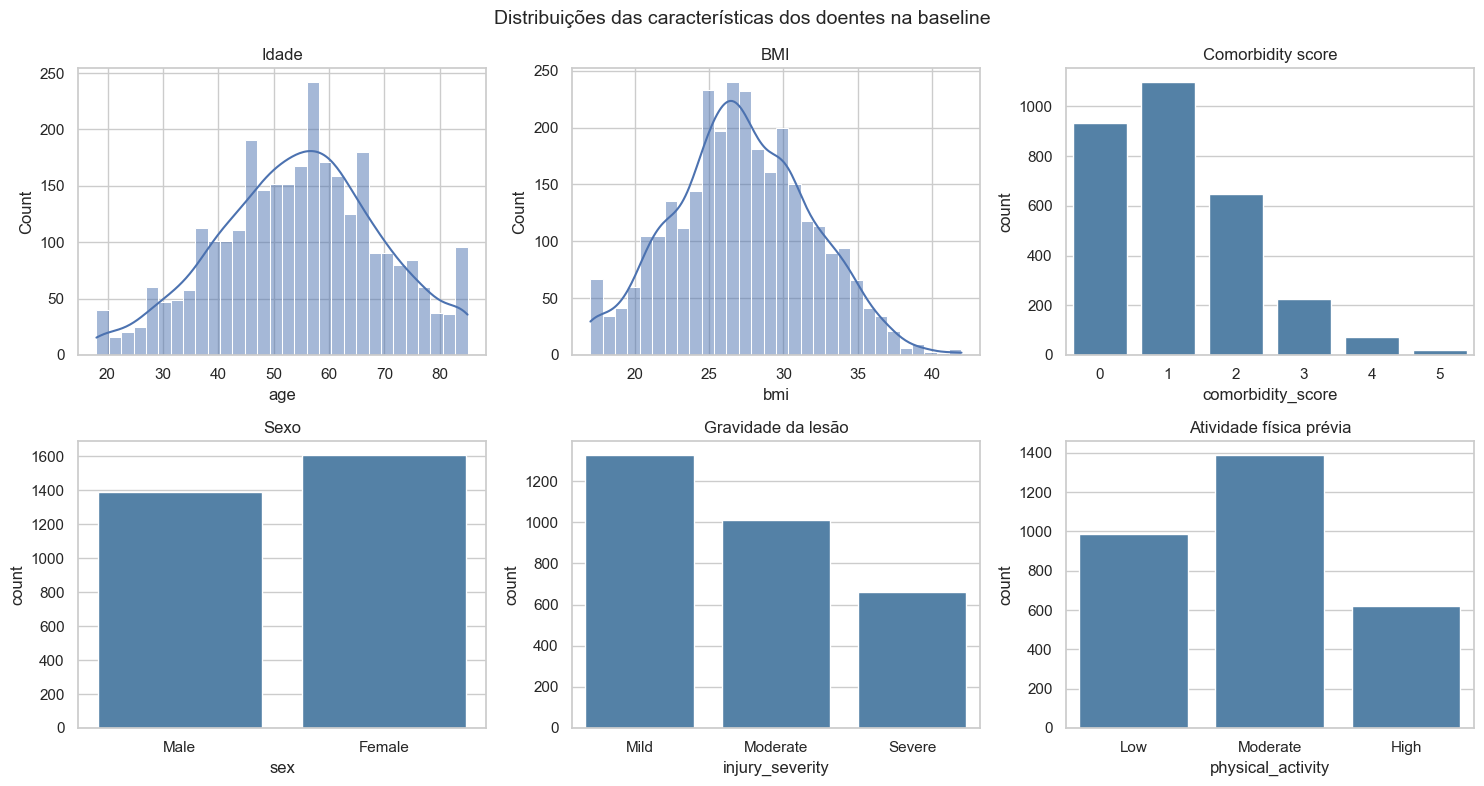

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sns.histplot(patients["age"], bins=30, kde=True, ax=axes[0, 0]); axes[0, 0].set_title("Idade")
sns.histplot(patients["bmi"], bins=30, kde=True, ax=axes[0, 1]); axes[0, 1].set_title("BMI")
sns.countplot(x="comorbidity_score", data=patients, ax=axes[0, 2], color="steelblue"); axes[0, 2].set_title("Comorbidity score")
sns.countplot(x="sex", data=patients, ax=axes[1, 0], color="steelblue"); axes[1, 0].set_title("Sexo")
sns.countplot(x="injury_severity", data=patients, order=SEV_ORDER, ax=axes[1, 1], color="steelblue"); axes[1, 1].set_title("Gravidade da lesão")
sns.countplot(x="physical_activity", data=patients, order=PA_ORDER, ax=axes[1, 2], color="steelblue"); axes[1, 2].set_title("Atividade física prévia")
plt.suptitle("Distribuições das características dos doentes na baseline", fontsize=14)
plt.tight_layout(); plt.show()

**Interpretação — características demográficas e clínicas:**
- **Idade:** média ≈ 54.5 anos (dp ≈ 14.7), entre 18 e 85 anos; distribuição aproximadamente simétrica/unimodal, concentrada entre os 40 e os 70 anos — plausível para uma população com lesões músculo-esqueléticas do membro inferior.
- **Sexo:** ligeiramente mais mulheres (≈ 53.6%) do que homens (≈ 46.4%).
- **BMI:** média ≈ 27.2 (excesso de peso), entre 17 e 42, com uma cauda ligeira à direita (alguns doentes com obesidade).
- **Gravidade da lesão:** predominam lesões ligeiras (Mild ≈ 44%), seguidas de moderadas (≈ 34%) e graves (≈ 22%).
- **Comorbilidades:** distribuição fortemente assimétrica à direita — a maioria tem 0–2 comorbilidades (mediana 1) e valores de 4–5 são raros.
- **Atividade física prévia:** Moderate é a categoria mais frequente (≈ 46%), seguida de Low (≈ 33%) e High (≈ 21%).

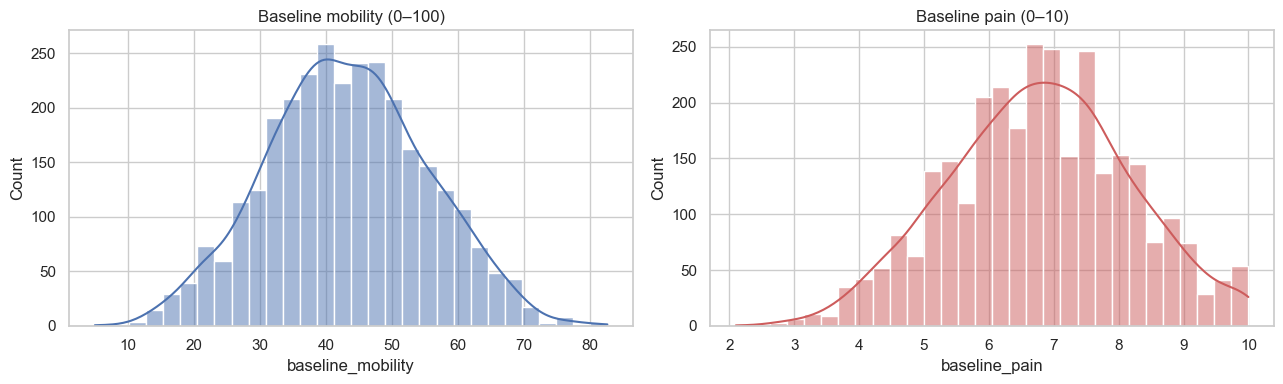

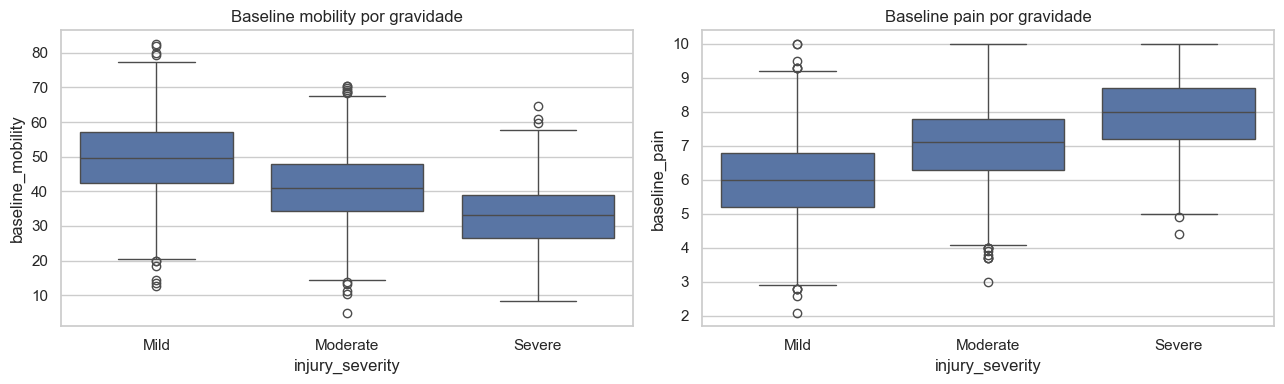

baseline_mobility        baseline_pain      
                             mean    std          mean   std
injury_severity                                             
Mild                        49.70  10.52          6.00  1.21
Moderate                    41.13  10.42          7.04  1.19
Severe                      33.09   9.25          7.94  1.13

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(patients["baseline_mobility"], bins=30, kde=True, ax=axes[0]); axes[0].set_title("Baseline mobility (0–100)")
sns.histplot(patients["baseline_pain"], bins=30, kde=True, ax=axes[1], color="indianred"); axes[1].set_title("Baseline pain (0–10)")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(x="injury_severity", y="baseline_mobility", data=patients, order=SEV_ORDER, ax=axes[0])
sns.boxplot(x="injury_severity", y="baseline_pain", data=patients, order=SEV_ORDER, ax=axes[1])
axes[0].set_title("Baseline mobility por gravidade"); axes[1].set_title("Baseline pain por gravidade")
plt.tight_layout(); plt.show()
display(patients.groupby("injury_severity")[["baseline_mobility", "baseline_pain"]].agg(["mean", "std"]).reindex(SEV_ORDER).round(2))

**Interpretação — mobilidade e dor na baseline:**
- A **mobilidade na baseline** é baixa-moderada (média ≈ 43/100, dp ≈ 12), aproximadamente simétrica, entre 5 e 83: no início da reabilitação a maioria dos doentes tem limitações funcionais importantes.
- A **dor na baseline** é elevada (média ≈ 6.8/10, dp ≈ 1.4), com assimetria à esquerda e alguns doentes no máximo (10).
- Ambas variam de forma consistente com a gravidade da lesão: lesões mais graves associam-se a **menor mobilidade** e **mais dor** no início — o que é clinicamente plausível.

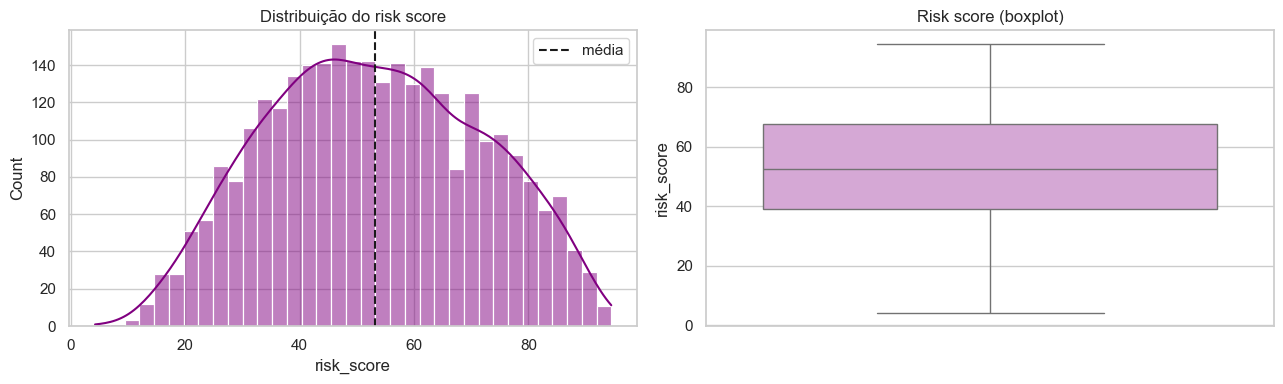

Assimetria (skew): 0.049
0.05    23.7
0.25    39.0
0.50    52.5
0.75    67.4
0.95    84.2
Name: risk_score, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(patients["risk_score"], bins=35, kde=True, ax=axes[0], color="purple")
axes[0].axvline(patients["risk_score"].mean(), ls="--", c="k", label="média"); axes[0].legend()
axes[0].set_title("Distribuição do risk score")
sns.boxplot(y=patients["risk_score"], ax=axes[1], color="plum"); axes[1].set_title("Risk score (boxplot)")
plt.tight_layout(); plt.show()
print(f"Assimetria (skew): {patients['risk_score'].skew():.3f}")
print(patients["risk_score"].quantile([.05, .25, .5, .75, .95]).round(1))

**Interpretação — risk score:** o índice de risco distribui-se de forma aproximadamente simétrica e unimodal em torno de ≈ 53 (dp ≈ 18.6), cobrindo quase toda a escala (≈ 4 a 95). Existe portanto **heterogeneidade considerável** no risco de uma recuperação desfavorável, sem grupos claramente separados apenas com base nesta variável.

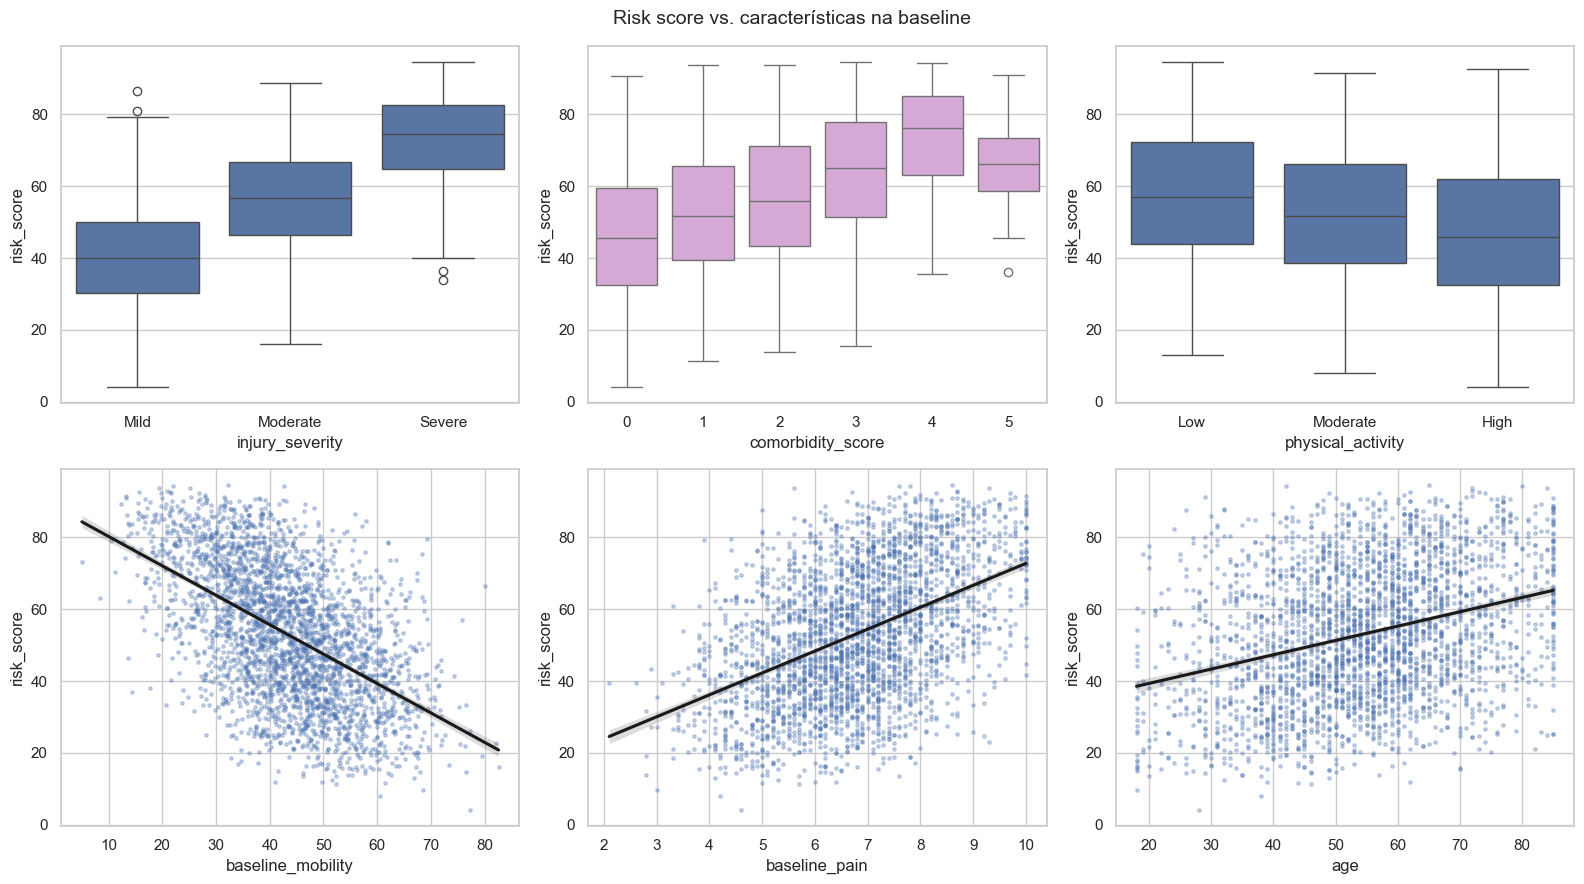

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
sns.boxplot(x="injury_severity", y="risk_score", data=patients, order=SEV_ORDER, ax=axes[0, 0])
sns.boxplot(x="comorbidity_score", y="risk_score", data=patients, ax=axes[0, 1], color="plum")
sns.boxplot(x="physical_activity", y="risk_score", data=patients, order=PA_ORDER, ax=axes[0, 2])
sns.regplot(x="baseline_mobility", y="risk_score", data=patients, ax=axes[1, 0], scatter_kws={"s": 6, "alpha": .3}, line_kws={"color": "k"})
sns.regplot(x="baseline_pain", y="risk_score", data=patients, ax=axes[1, 1], scatter_kws={"s": 6, "alpha": .3}, line_kws={"color": "k"})
sns.regplot(x="age", y="risk_score", data=patients, ax=axes[1, 2], scatter_kws={"s": 6, "alpha": .3}, line_kws={"color": "k"})
plt.suptitle("Risk score vs. características na baseline", fontsize=14)
plt.tight_layout(); plt.show()

,count,mean,median,std
injury_severity,,,,
Mild,1327,40.67,40.10,13.88
Moderate,1010,56.36,56.65,14.17
Severe,663,73.07,74.50,11.96


,count,mean,median,std
physical_activity,,,,
Low,988,57.78,57.1,17.89
Moderate,1389,52.43,51.6,18.27
High,623,47.22,46.0,18.39


,count,mean,median
comorbidity_score,,,
0,935,46.72,45.70
1,1098,52.64,51.60
2,648,56.97,55.90
3,226,63.45,65.15
4,73,72.00,76.30
5,20,66.76,66.20


,count,mean,median
sex,,,
Female,1608,53.02,52.3
Male,1392,53.22,53.1


,pearson,spearman
injury_severity_ord,0.682,0.677
baseline_mobility,-0.535,-0.530
baseline_pain,0.463,0.452
age,0.316,0.304
comorbidity_score,0.311,0.290
physical_activity_ord,-0.206,-0.198
bmi,0.060,0.054
sex_male,0.005,0.005


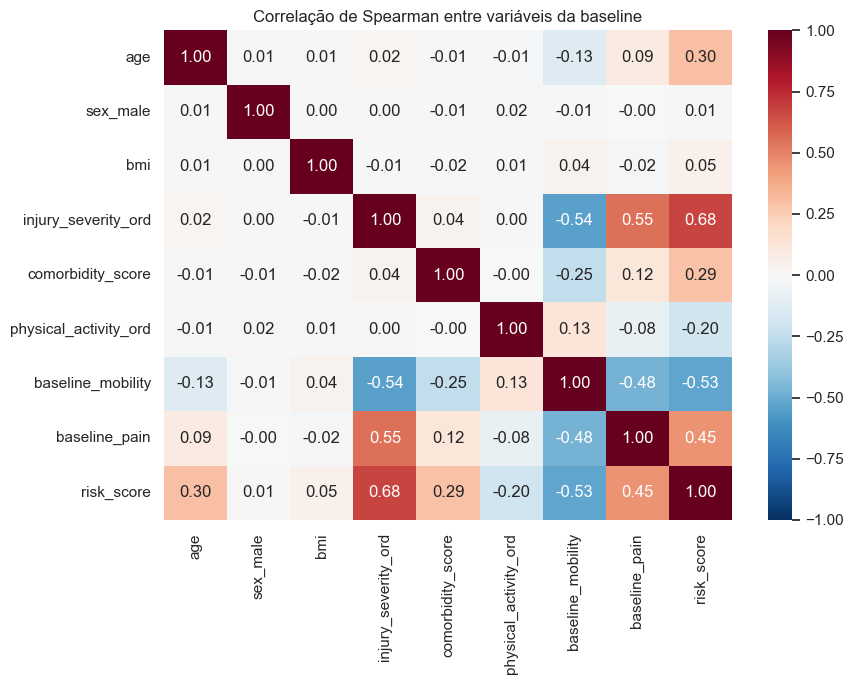

In [12]:
display(patients.groupby("injury_severity")["risk_score"].agg(["count", "mean", "median", "std"]).reindex(SEV_ORDER).round(2))
display(patients.groupby("physical_activity")["risk_score"].agg(["count", "mean", "median", "std"]).reindex(PA_ORDER).round(2))
display(patients.groupby("comorbidity_score")["risk_score"].agg(["count", "mean", "median"]).round(2))
display(patients.groupby("sex")["risk_score"].agg(["count", "mean", "median"]).round(2))

# Correlações (Pearson e Spearman) com as variáveis numéricas + variáveis ordinais codificadas
enc = patients.copy()
enc["injury_severity_ord"] = enc["injury_severity"].map({k: i for i, k in enumerate(SEV_ORDER)})
enc["physical_activity_ord"] = enc["physical_activity"].map({k: i for i, k in enumerate(PA_ORDER)})
enc["sex_male"] = (enc["sex"] == "Male").astype(int)
cols = ["age", "sex_male", "bmi", "injury_severity_ord", "comorbidity_score", "physical_activity_ord",
        "baseline_mobility", "baseline_pain", "risk_score"]
corr_risk = pd.DataFrame({"pearson": enc[cols].corr()["risk_score"],
                          "spearman": enc[cols].corr(method="spearman")["risk_score"]}).drop("risk_score")
display(corr_risk.sort_values("spearman", key=abs, ascending=False).round(3))

plt.figure(figsize=(9, 7))
sns.heatmap(enc[cols].corr(method="spearman"), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Correlação de Spearman entre variáveis da baseline"); plt.tight_layout(); plt.show()

**Interpretação — relação entre o risk score e as características na baseline:**
- **Gravidade da lesão** é o fator com a relação mais forte (Spearman ≈ 0.68): o risco médio sobe de ≈ 41 (Mild) para ≈ 56 (Moderate) e ≈ 73 (Severe), com pouca sobreposição entre os extremos.
- **Baseline mobility** tem uma correlação negativa moderada/forte com o risco (r ≈ −0.53): quem começa com menos mobilidade tem maior risco.
- **Baseline pain** (r ≈ +0.46), **idade** (r ≈ +0.32) e **comorbilidades** (r ≈ +0.31) associam-se positivamente ao risco; a relação com as comorbilidades é aproximadamente monótona (≈ 47 com 0 comorbilidades até ≈ 72 com 4; o grupo com 5 tem apenas 20 doentes).
- A **atividade física prévia** associa-se a menor risco (Low ≈ 58, Moderate ≈ 52, High ≈ 47), enquanto **BMI** e **sexo** têm relação fraca/praticamente nula.

O `risk_score` parece portanto ser um índice composto das restantes variáveis de baseline. Isto tem implicações para os milestones seguintes: por ser em grande parte **redundante** com gravidade, mobilidade, dor, idade e comorbilidades, numa Bayesian network o `risk_score` deverá surgir como filho destas variáveis (ou como resumo que as substitui), e incluí-lo juntamente com todas elas num modelo pode introduzir colinearidade. Note-se também que as variáveis de baseline estão correlacionadas entre si (p.ex. gravidade ↔ mobilidade/dor), pelo que as associações acima não são efeitos isolados.

## Task 3 — Estados de recuperação e trajetórias
*(`rehabilitation.csv`)*

,n,%
state,,
Limited,13829,32.93
Recovering,18088,43.07
Functional,10083,24.01


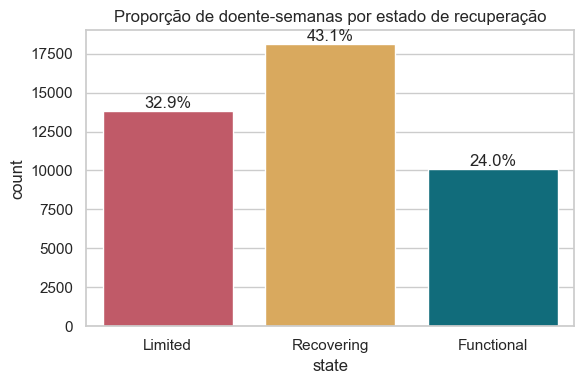

In [13]:
state_counts = rehab["state"].value_counts().reindex(STATE_ORDER)
display(pd.DataFrame({"n": state_counts, "%": (100 * state_counts / len(rehab)).round(2)}))

plt.figure(figsize=(6, 4))
ax = sns.countplot(x="state", data=rehab, order=STATE_ORDER, palette=STATE_PAL, hue="state", legend=False)
for p_ in ax.patches:
    ax.annotate(f"{100 * p_.get_height() / len(rehab):.1f}%", (p_.get_x() + p_.get_width() / 2, p_.get_height()),
                ha="center", va="bottom")
plt.title("Proporção de doente-semanas por estado de recuperação"); plt.tight_layout(); plt.show()

**Proporção por estado:** Recovering ≈ 43.1%, Limited ≈ 32.9% e Functional ≈ 24.0% dos doente-semanas. As classes estão algo desequilibradas — o estado Functional é o menos representado, em parte porque os doentes só lá chegam após várias semanas (ver abaixo).

week,0,1,2,3,4,5,6,7,8,9,10,11,12,13
state,,,,,,,,,,,,,,
Limited,68.8,61.6,54.0,46.9,40.9,36.0,30.6,26.7,22.7,19.9,17.0,14.4,11.7,9.8
Recovering,31.1,38.0,44.6,49.7,51.5,51.9,51.8,49.9,47.3,43.3,40.3,37.3,34.2,32.2
Functional,0.1,0.5,1.5,3.4,7.6,12.2,17.6,23.4,29.9,36.8,42.7,48.4,54.1,58.0


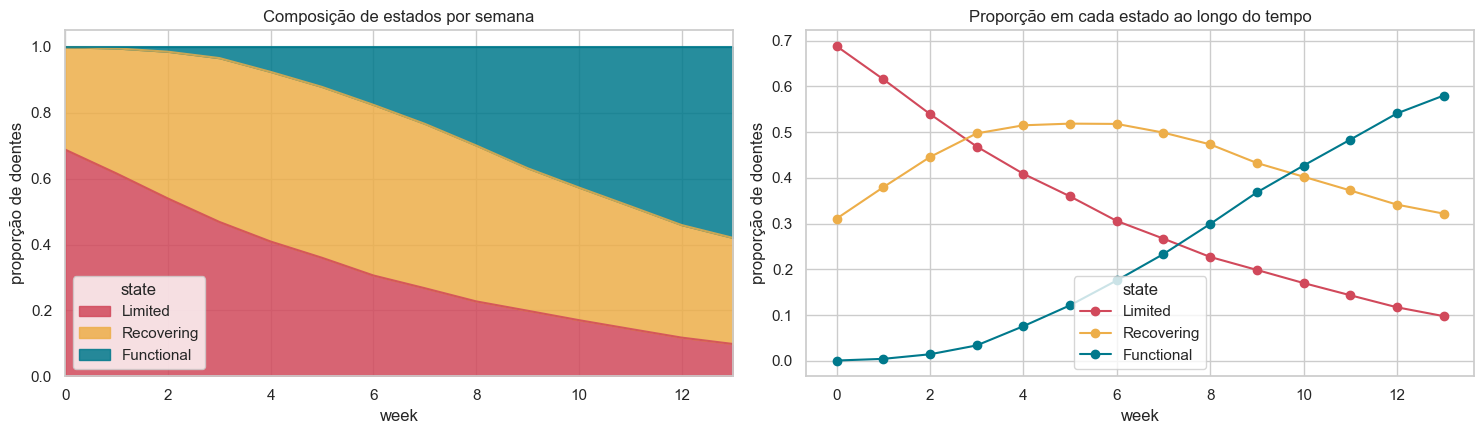

In [14]:
state_by_week = pd.crosstab(rehab["week"], rehab["state"], normalize="index")[STATE_ORDER]
display((100 * state_by_week).round(1).T)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
state_by_week.plot(kind="area", stacked=True, color=[STATE_PAL[s] for s in STATE_ORDER], alpha=.85, ax=axes[0])
axes[0].set_ylabel("proporção de doentes"); axes[0].set_title("Composição de estados por semana"); axes[0].set_xlim(0, 13)
state_by_week.plot(marker="o", color=[STATE_PAL[s] for s in STATE_ORDER], ax=axes[1])
axes[1].set_ylabel("proporção de doentes"); axes[1].set_title("Proporção em cada estado ao longo do tempo")
plt.tight_layout(); plt.show()

**Evolução temporal:** na semana 0, ≈ 69% dos doentes estão em Limited, ≈ 31% em Recovering e praticamente nenhum em Functional. Ao longo do tempo:
- a proporção em **Limited** diminui monotonamente (≈ 10% na semana 13);
- **Recovering** cresce até um máximo de ≈ 52% nas semanas 4–6 e depois decresce ligeiramente (≈ 32% no fim) — é um estado de **transição**, alimentado por Limited e que vai "escoando" para Functional;
- **Functional** só surge a partir da semana ≈ 2 e cresce continuamente até ≈ 58% na semana 13.

Isto é compatível com uma progressão ordenada Limited → Recovering → Functional, o que sugere que um modelo de Markov (M5) com transições sobretudo "para a frente" será adequado. Note-se ainda que no fim do período cerca de 42% dos doentes **ainda não atingiram** o estado Functional.

In [15]:
# Análise por doente: codificar estado como ordinal e caracterizar trajetórias
S = {"Limited": 0, "Recovering": 1, "Functional": 2}
rs = rehab.sort_values(["patient_id", "week"]).copy()
rs["s"] = rs["state"].map(S)
rs["ds"] = rs.groupby("patient_id")["s"].diff()

traj = rs.groupby("patient_id").agg(
    start=("s", "first"), end=("s", "last"),
    n_changes=("ds", lambda d: (d.fillna(0) != 0).sum()),
    n_setbacks=("ds", lambda d: (d < 0).sum()),
    n_jumps=("ds", lambda d: (d.abs() == 2).sum()),
)
first_func = rs[rs["s"] == 2].groupby("patient_id")["week"].min()
traj["week_first_functional"] = first_func

inv = {v: k for k, v in S.items()}
print("Estado inicial (semana 0) × estado final (semana 13) — nº de doentes:")
display(pd.crosstab(traj["start"].map(inv), traj["end"].map(inv)).reindex(index=STATE_ORDER, columns=STATE_ORDER, fill_value=0))

print(f"Doentes que atingem Functional em algum momento: {traj['week_first_functional'].notna().sum()} "
      f"({100 * traj['week_first_functional'].notna().mean():.1f}%)")
print(f"Doentes que nunca mudam de estado:              {(traj['n_changes'] == 0).sum()}")
print(f"Doentes que ficam sempre em Limited:            {((traj['n_changes'] == 0) & (traj['start'] == 0)).sum()}")
print(f"Doentes com pelo menos um retrocesso (setback): {(traj['n_setbacks'] > 0).sum()} "
      f"({100 * (traj['n_setbacks'] > 0).mean():.1f}%)")
print(f"Nº total de semanas com retrocesso:             {int(traj['n_setbacks'].sum())}")
print(f"Transições que saltam um estado (L<->F):        {int(traj['n_jumps'].sum())}")

# Matriz empírica de transição semana t -> t+1
rs["next_state"] = rs.groupby("patient_id")["state"].shift(-1)
T = pd.crosstab(rs["state"], rs["next_state"], normalize="index").reindex(index=STATE_ORDER, columns=STATE_ORDER)
print("\nMatriz de transição empírica P(estado_{t+1} | estado_t):")
display(T.round(3))

Estado inicial (semana 0) × estado final (semana 13) — nº de doentes:


end,Limited,Recovering,Functional
start,,,
Limited,294,922,848
Recovering,0,44,889
Functional,0,0,3


Doentes que atingem Functional em algum momento: 1818 (60.6%)
Doentes que nunca mudam de estado:              276
Doentes que ficam sempre em Limited:            261
Doentes com pelo menos um retrocesso (setback): 454 (15.1%)
Nº total de semanas com retrocesso:             493
Transições que saltam um estado (L<->F):        0

Matriz de transição empírica P(estado_{t+1} | estado_t):


next_state,Limited,Recovering,Functional
state,,,
Limited,0.856,0.144,0.000
Recovering,0.010,0.870,0.120
Functional,0.000,0.038,0.962


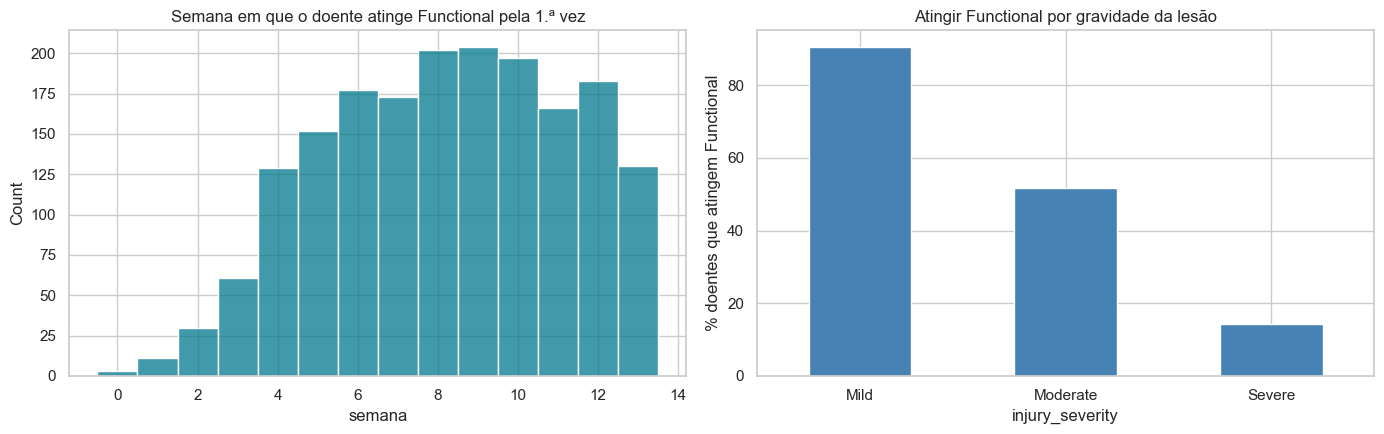

,reached,median_week
injury_severity,,
Mild,90.5,7.0
Moderate,51.8,10.0
Severe,14.2,11.0


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(traj["week_first_functional"].dropna(), bins=np.arange(-0.5, 14.5, 1), ax=axes[0], color=STATE_PAL["Functional"])
axes[0].set_title("Semana em que o doente atinge Functional pela 1.ª vez"); axes[0].set_xlabel("semana")

pf = patients.set_index("patient_id").join(traj)
reach = pf.groupby("injury_severity")["week_first_functional"].agg(
    reached=lambda x: 100 * x.notna().mean(), median_week="median").reindex(SEV_ORDER)
reach["reached"].plot(kind="bar", ax=axes[1], color="steelblue", rot=0)
axes[1].set_ylabel("% doentes que atingem Functional"); axes[1].set_title("Atingir Functional por gravidade da lesão")
plt.tight_layout(); plt.show()
display(reach.round(1))

{'Recuperação rápida': 2452, 'Recuperação gradual': 1820, 'Sempre Limited (sem progressão)': 1503, 'Com retrocessos (setbacks)': 1137}


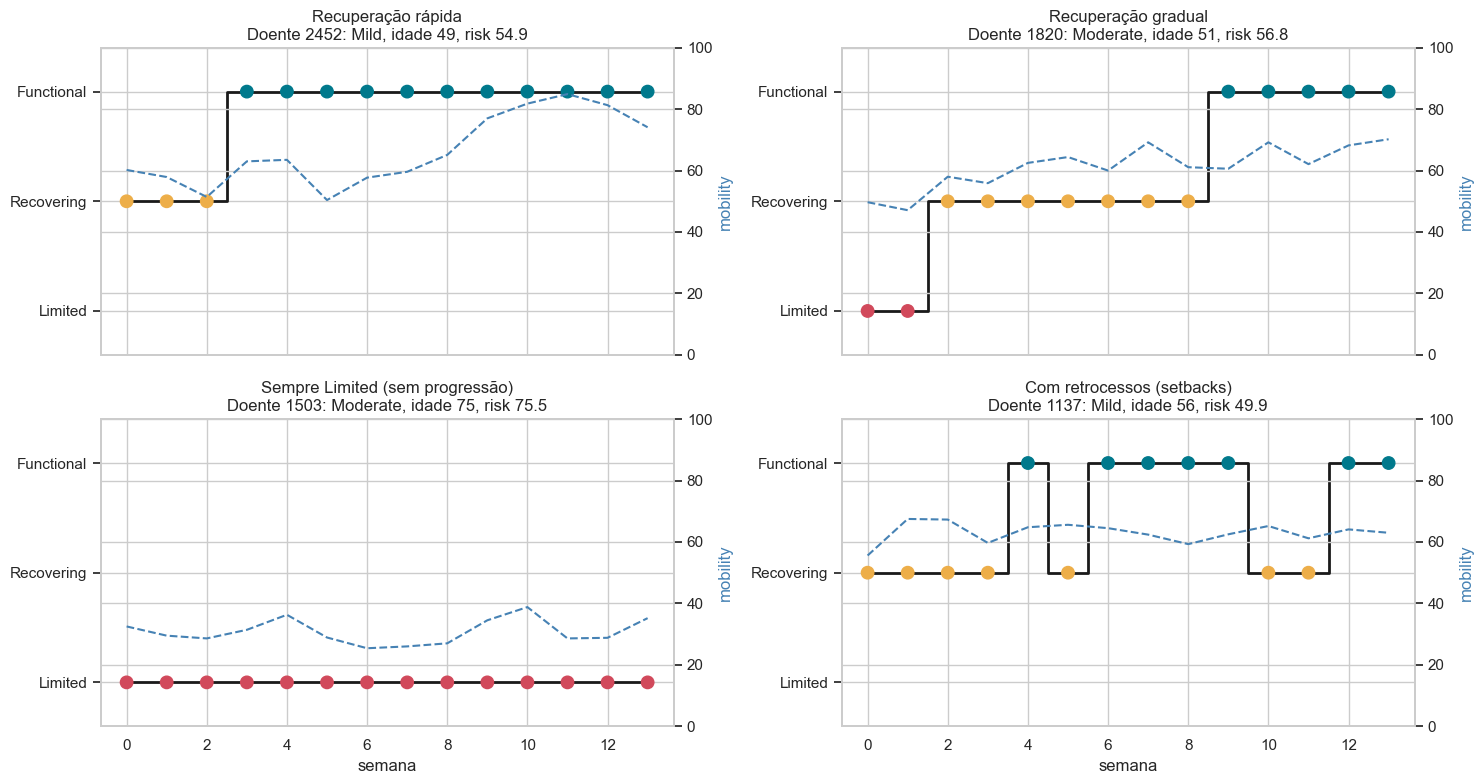

In [17]:
# Selecionar doentes ilustrativos de diferentes tipos de trajetória
rng = np.random.default_rng(0)
examples = {
    "Recuperação rápida": traj[traj["week_first_functional"] <= 4].index,
    "Recuperação gradual": traj[(traj["start"] == 0) & (traj["week_first_functional"].between(8, 10)) & (traj["n_setbacks"] == 0)].index,
    "Sempre Limited (sem progressão)": traj[(traj["n_changes"] == 0) & (traj["start"] == 0)].index,
    "Com retrocessos (setbacks)": traj[traj["n_setbacks"] >= 2].index,
}
chosen = {k: int(rng.choice(v)) for k, v in examples.items()}
print(chosen)

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
for ax, (label, pid) in zip(axes.ravel(), chosen.items()):
    d = rs[rs["patient_id"] == pid]
    ax.step(d["week"], d["s"], where="mid", color="k", lw=2, label="estado")
    ax.scatter(d["week"], d["s"], c=d["state"].map(STATE_PAL), s=80, zorder=3)
    ax.set_yticks([0, 1, 2]); ax.set_yticklabels(STATE_ORDER); ax.set_ylim(-.4, 2.4)
    ax2 = ax.twinx(); ax2.plot(d["week"], d["mobility"], "--", color="steelblue", label="mobility"); ax2.set_ylim(0, 100)
    ax2.set_ylabel("mobility", color="steelblue")
    info = patients.set_index("patient_id").loc[pid]
    ax.set_title(f"{label}\nDoente {pid}: {info['injury_severity']}, idade {info['age']}, risk {info['risk_score']}")
for ax in axes[1]: ax.set_xlabel("semana")
plt.tight_layout(); plt.show()

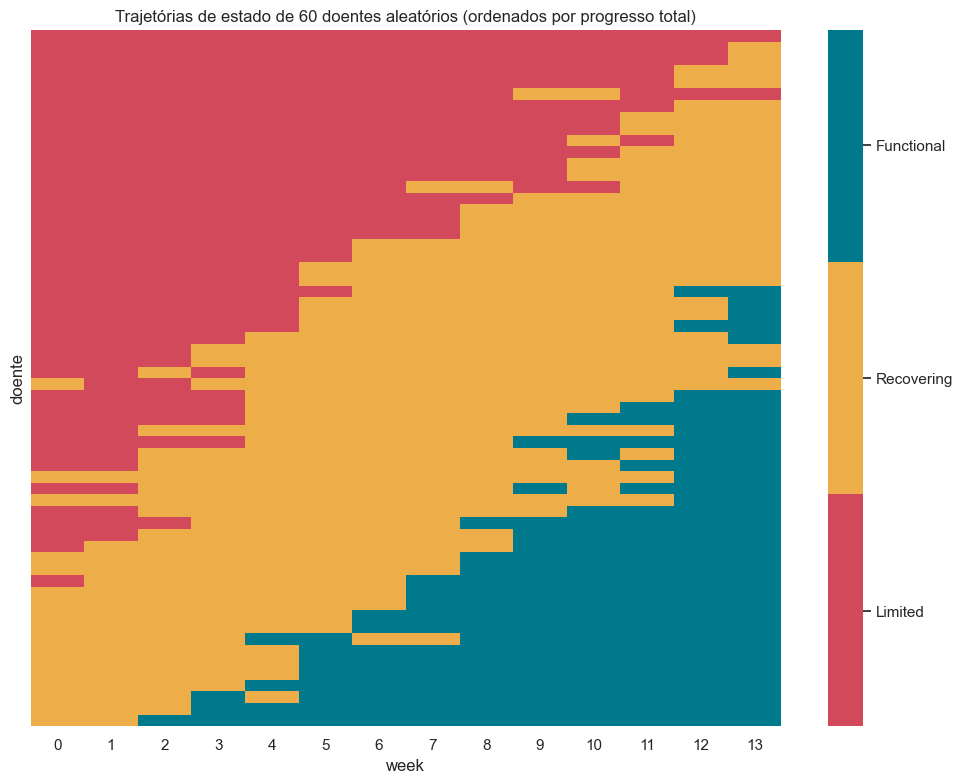

In [18]:
# Visão agregada de trajetórias: 60 doentes aleatórios (linhas = doentes, colunas = semanas)
from matplotlib.colors import ListedColormap
sample_ids = rng.choice(rs["patient_id"].unique(), 60, replace=False)
mat = rs[rs["patient_id"].isin(sample_ids)].pivot(index="patient_id", columns="week", values="s")
mat = mat.loc[mat.sum(axis=1).sort_values().index]
plt.figure(figsize=(10, 8))
sns.heatmap(mat, cmap=ListedColormap([STATE_PAL[s] for s in STATE_ORDER]), cbar_kws={"ticks": [0.33, 1, 1.67]}, yticklabels=False)
plt.gcf().axes[-1].set_yticklabels(STATE_ORDER)
plt.title("Trajetórias de estado de 60 doentes aleatórios (ordenados por progresso total)"); plt.ylabel("doente")
plt.tight_layout(); plt.show()

**Os doentes seguem trajetórias semelhantes?** Não. Existe uma tendência geral de melhoria, mas com grande **heterogeneidade**:
- **Recuperação rápida:** alguns doentes atingem Functional nas primeiras 3–4 semanas (tipicamente lesões Mild, baixo risco).
- **Recuperação gradual:** o padrão mais comum é Limited → Recovering → Functional, com permanência de várias semanas em cada estado.
- **Estabilidade / sem progressão:** um grupo não negligenciável de doentes permanece em Limited durante as 14 semanas, e muitos terminam em Recovering sem atingir Functional.
- **Retrocessos:** cerca de 15% dos doentes têm pelo menos uma semana em que o estado piora (p.ex. Recovering → Limited ou Functional → Recovering), o que corresponde às "temporary setbacks" descritas no enunciado.

A matriz de transição mostra que os estados são muito **persistentes** (diagonal: 0.86 / 0.87 / 0.96), que as transições ocorrem apenas entre estados **adjacentes** (não há nenhum salto direto Limited ↔ Functional) e que as transições para a frente (L→R 14%, R→F 12%) são muito mais prováveis do que os retrocessos (R→L 1%, F→R 4%). No total, ≈ 61% dos doentes atingem Functional em algum momento, 261 permanecem em Limited durante as 14 semanas e 454 (≈ 15%) têm pelo menos um retrocesso. A velocidade de recuperação depende claramente da **gravidade da lesão**: ≈ 90% dos doentes Mild atingem Functional (mediana: semana 7), contra ≈ 52% dos Moderate (semana 10) e apenas ≈ 14% dos Severe (semana 11). Estes padrões motivam modelos temporais com estados latentes (HMM, M5) e a inclusão de características de baseline como fatores que condicionam a dinâmica.

## Task 4 — Medições funcionais e reportadas pelo doente

,count,mean,std,min,25%,50%,75%,max,skew
mobility,42000.0,54.61,15.21,3.2,43.7,54.5,65.5,100.0,0.02
pain,42000.0,5.66,1.70,0.0,4.5,5.7,6.9,10.0,-0.04
fatigue,42000.0,5.47,1.48,0.0,4.4,5.5,6.5,10.0,-0.02
functional_confidence,42000.0,53.01,16.15,0.0,41.3,52.6,64.7,100.0,0.06
activity,42000.0,40.45,17.49,0.0,27.7,40.3,52.9,103.4,0.07
adherence,42000.0,61.15,15.52,8.0,50.5,62.3,73.1,98.4,-0.34


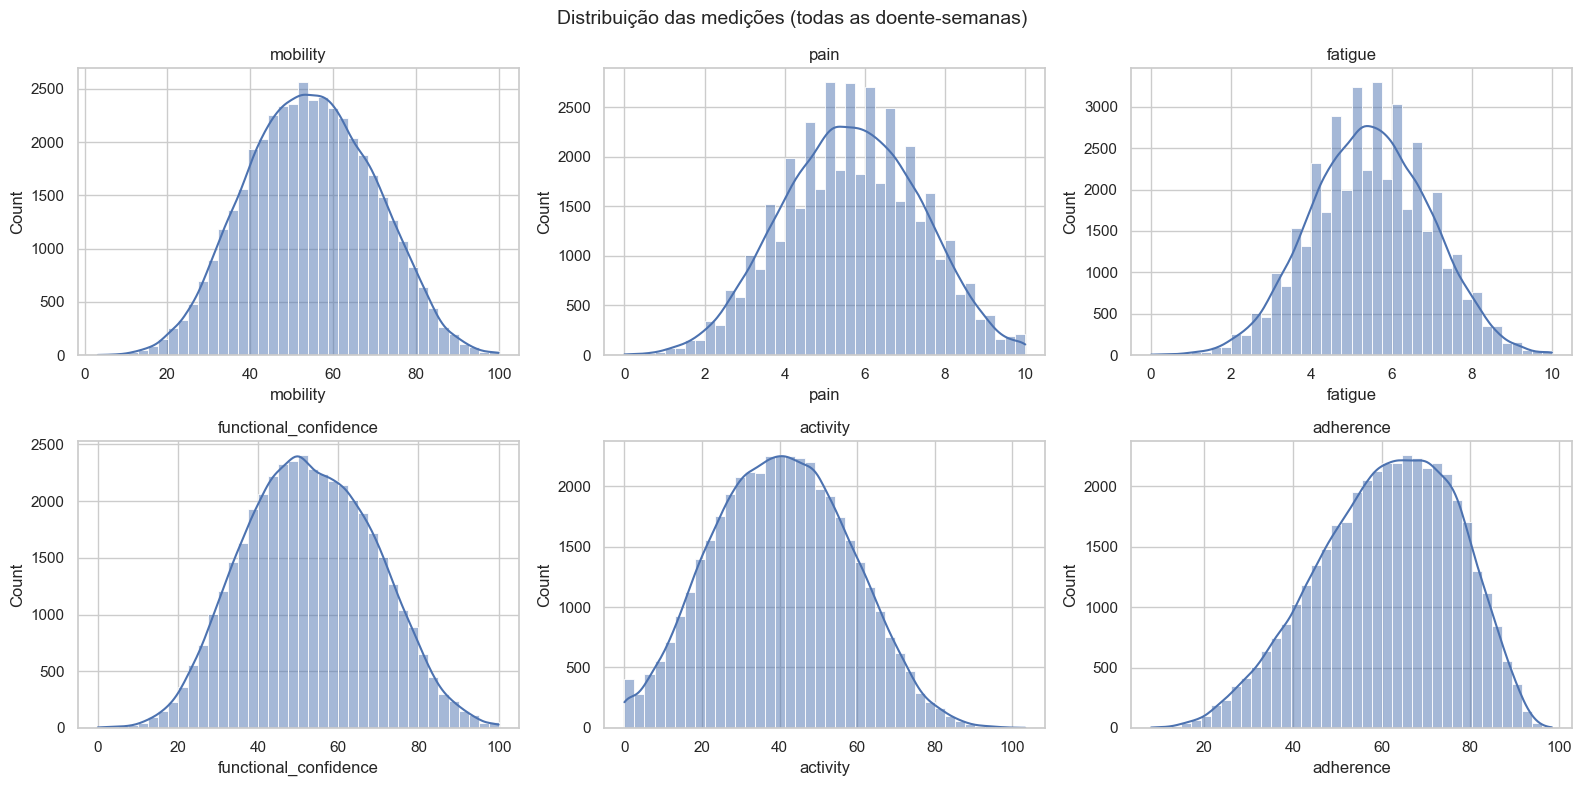

In [19]:
display(rehab[MEASURES].describe().T.round(2).assign(skew=rehab[MEASURES].skew().round(2).values))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), MEASURES):
    sns.histplot(rehab[c], bins=40, kde=True, ax=ax)
    ax.set_title(c)
plt.suptitle("Distribuição das medições (todas as doente-semanas)", fontsize=14)
plt.tight_layout(); plt.show()

**Distribuições globais:**
- `mobility` (média ≈ 55, dp ≈ 15) e `functional_confidence` (média ≈ 53, dp ≈ 16) são largas e aproximadamente simétricas, refletindo a mistura de doentes em fases muito diferentes da recuperação; atingem os limites 0/100 em raros casos.
- `pain` (média ≈ 5.7) e `fatigue` (média ≈ 5.5) estão a meio/metade superior da escala 0–10, aproximadamente simétricas, com uma pequena acumulação no máximo (10) no caso da dor (121 observações).
- `activity` (média ≈ 40, escala 0–110) tem uma acumulação visível em **0** (efeito de chão / *clipping*), resultante de doentes muito limitados.
- `adherence` (média ≈ 61, dp ≈ 16) é aproximadamente simétrica e, como veremos, quase não depende do estado.

Uma distribuição global larga, por vezes com "ombros", é consistente com a sobreposição de subpopulações (estados) — o que motiva o uso de mixture models no M1.

,mobility,pain,fatigue,functional_confidence,activity,adherence
state,,,,,,
Limited,40.20,7.13,6.54,37.61,24.73,58.81
Recovering,56.17,5.50,5.36,54.62,42.22,61.69
Functional,71.58,3.92,4.17,71.23,58.85,63.38


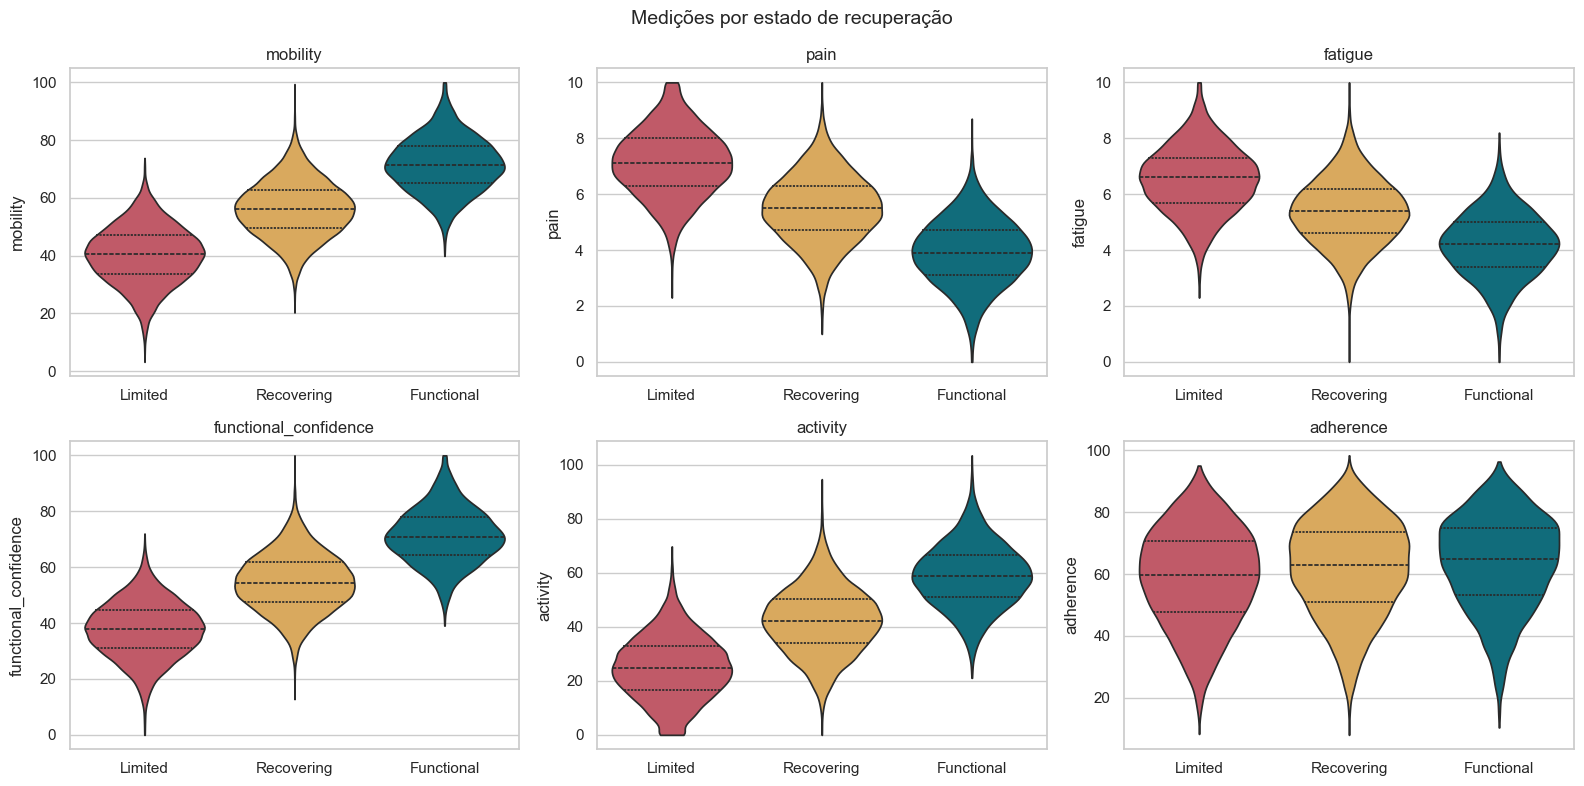

In [20]:
display(rehab.groupby("state")[MEASURES].mean().reindex(STATE_ORDER).round(2))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), MEASURES):
    sns.violinplot(x="state", y=c, data=rehab, order=STATE_ORDER, palette=STATE_PAL, hue="state", legend=False, ax=ax, inner="quartile", cut=0)
    ax.set_title(c); ax.set_xlabel("")
plt.suptitle("Medições por estado de recuperação", fontsize=14)
plt.tight_layout(); plt.show()

In [21]:
# Teste de Normalidade (Kolmogorov-Smirnov)
# Motivado pela metodologia do projeto ECAC, testamos formalmente a normalidade antes de aplicar testes não paramétricos.
from scipy import stats
import pandas as pd

ks_results = []
for c in MEASURES:
    stat, p_val = stats.kstest(rehab[c].dropna(), 'norm', args=(rehab[c].mean(), rehab[c].std()))
    ks_results.append({'Variável': c, 'KS-Statistic': stat, 'p-value': p_val, 'Normal? (p>0.05)': p_val > 0.05})

display(pd.DataFrame(ks_results).set_index('Variável'))
print('Como o p-value é < 0.05 para todas as variáveis, rejeitamos a hipótese nula de normalidade.')
print('Isto justifica formalmente o uso do teste não-paramétrico de Kruskal-Wallis a seguir.')

,KS-Statistic,p-value,Normal? (p>0.05)
Variável,,,
mobility,0.016577,1.865304e-10,False
pain,0.022482,7.146132e-19,False
fatigue,0.018026,2.761049e-12,False
functional_confidence,0.020087,3.751583e-15,False
activity,0.018729,3.145555e-13,False
adherence,0.039093,3.301817e-56,False


Como o p-value é < 0.05 para todas as variáveis, rejeitamos a hipótese nula de normalidade.
Isto justifica formalmente o uso do teste não-paramétrico de Kruskal-Wallis a seguir.


In [22]:
# Tamanho de efeito: fração da variância de cada medição explicada pelo estado (eta^2) — quão bem cada variável separa os estados
from scipy import stats
rows = []
for c in MEASURES:
    groups = [rehab.loc[rehab["state"] == s, c] for s in STATE_ORDER]
    grand = rehab[c].mean()
    ss_between = sum(len(g) * (g.mean() - grand) ** 2 for g in groups)
    ss_total = ((rehab[c] - grand) ** 2).sum()
    H, p = stats.kruskal(*groups)
    rows.append({"variável": c, "eta²": ss_between / ss_total, "Kruskal-Wallis H": H, "p-value": p})
display(pd.DataFrame(rows).set_index("variável").sort_values("eta²", ascending=False).round(4))

,eta²,Kruskal-Wallis H,p-value
variável,,,
functional_confidence,0.6089,26336.3853,0.0
mobility,0.5986,25873.7057,0.0
activity,0.5363,23072.1616,0.0
pain,0.4996,21478.5927,0.0
fatigue,0.3615,15393.1588,0.0
adherence,0.0129,525.5762,0.0


**Diferenças entre estados:** sim, as medições diferem claramente entre estados e de forma **monótona** e clinicamente coerente:
- De Limited → Recovering → Functional, `mobility`, `functional_confidence` e `activity` **aumentam** (p.ex. mobilidade média ≈ 40 → 56 → 72), enquanto `pain` e `fatigue` **diminuem** (dor média ≈ 7.1 → 5.5 → 3.9).
- O η² mostra que `functional_confidence` (0.61) e `mobility` (0.60) são as variáveis que melhor separam os estados, seguidas de `activity` (0.54), `pain` (0.50) e `fatigue` (0.36).
- `adherence` praticamente **não** difere entre estados (≈ 59 / 62 / 63; η² ≈ 0.01): mede o comportamento do doente e não o seu estado funcional.

Ainda assim, as distribuições **sobrepõem-se** bastante, sobretudo entre estados adjacentes (Limited/Recovering e Recovering/Functional). Nenhuma medição isolada identifica o estado com certeza: o estado é **latente** e só observável indiretamente e com ruído — exatamente o cenário para o qual modelos probabilísticos (GMM, Bayesian networks, HMM) são adequados. (Os testes de Kruskal-Wallis dão p ≈ 0, mas com n = 42 000 a significância é trivial; o tamanho de efeito é mais informativo.)

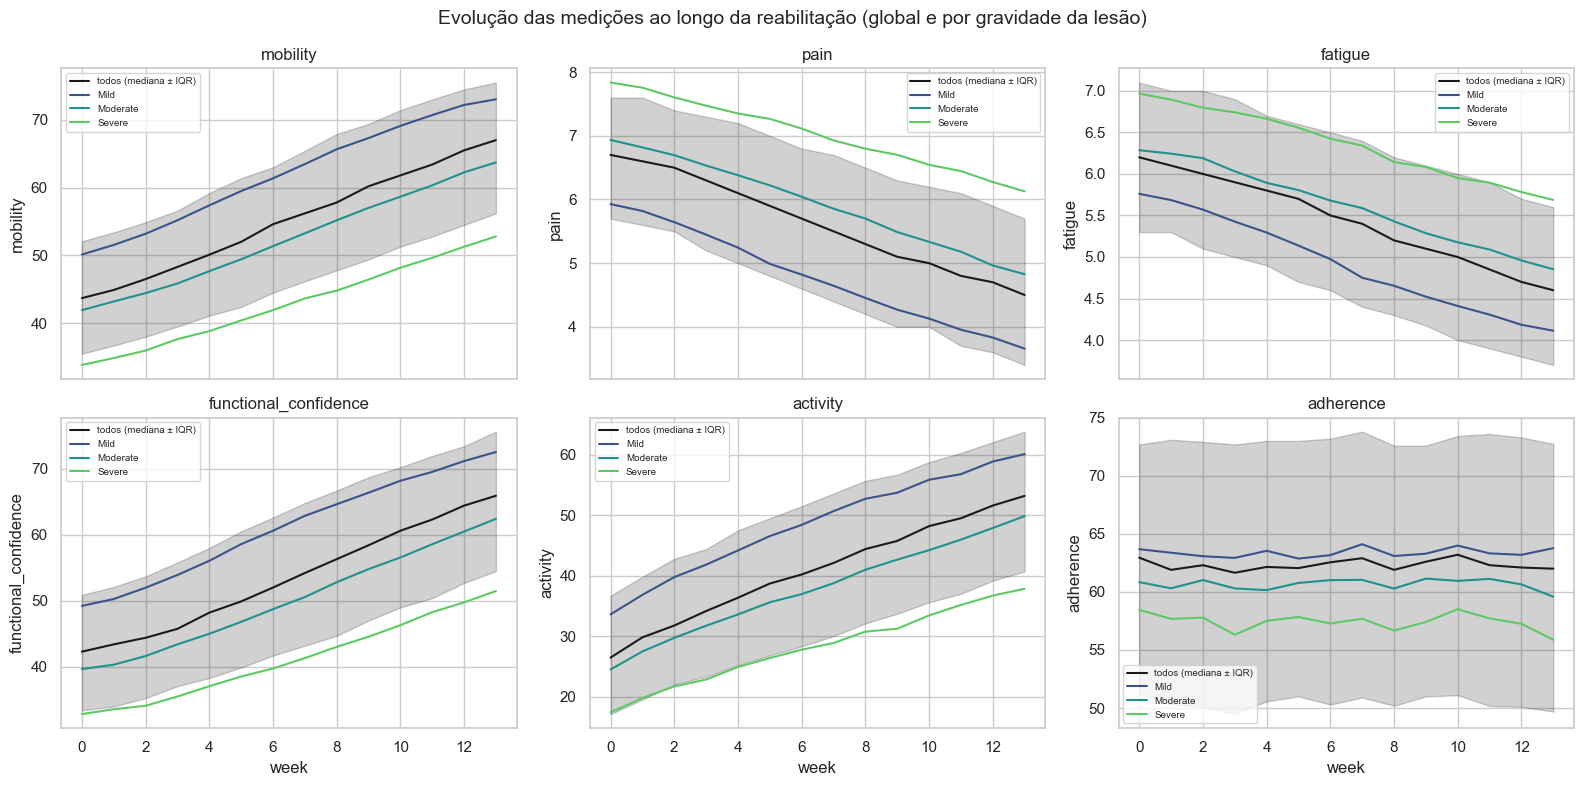

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
for ax, c in zip(axes.ravel(), MEASURES):
    sns.lineplot(x="week", y=c, data=rehab, ax=ax, color="k", errorbar=("pi", 50), label="todos (mediana ± IQR)", estimator="median")
    sns.lineplot(x="week", y=c, hue="injury_severity", hue_order=SEV_ORDER, data=merged, ax=ax, errorbar=None, palette="viridis")
    ax.set_title(c); ax.legend(fontsize=7)
plt.suptitle("Evolução das medições ao longo da reabilitação (global e por gravidade da lesão)", fontsize=14)
plt.tight_layout(); plt.show()

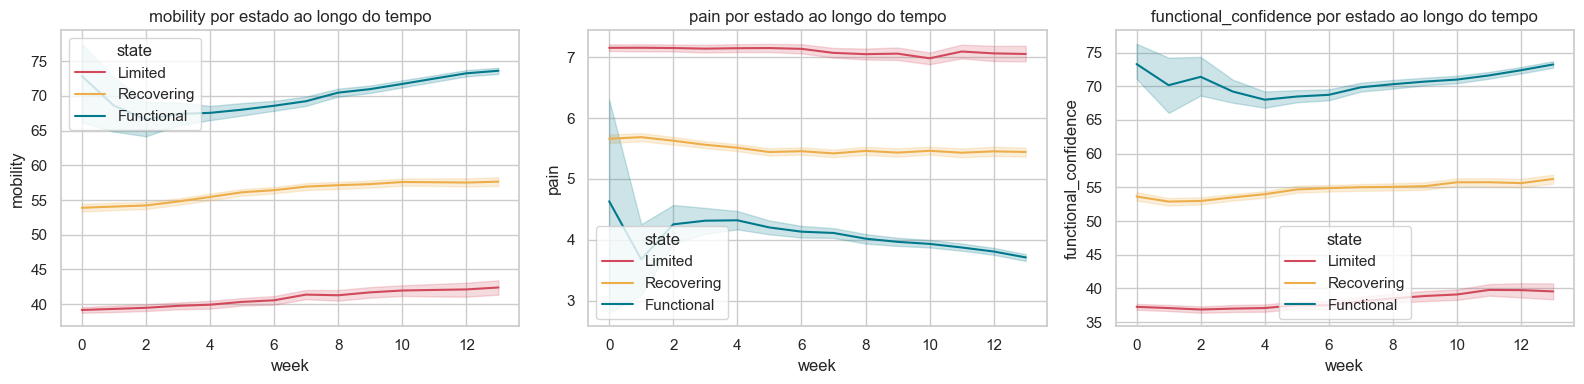

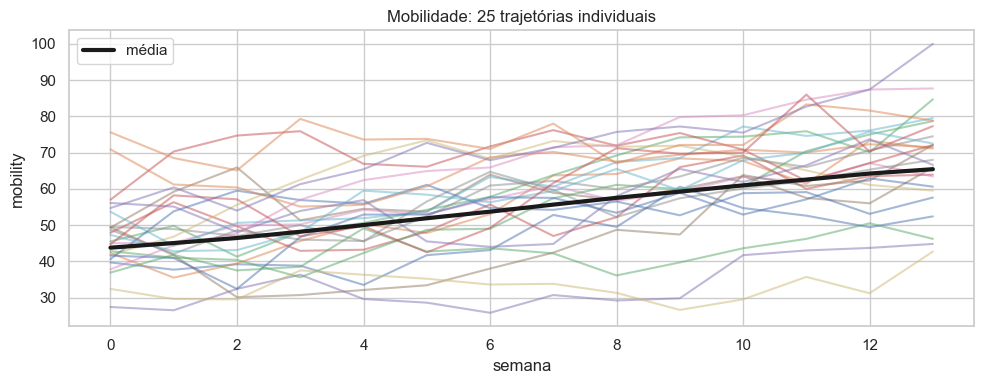

In [24]:
# Evolução da média dentro de cada estado: separar o efeito "composição de estados" do efeito "tempo"
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, ["mobility", "pain", "functional_confidence"]):
    sns.lineplot(x="week", y=c, hue="state", hue_order=STATE_ORDER, palette=STATE_PAL, data=rehab, ax=ax)
    ax.set_title(f"{c} por estado ao longo do tempo")
plt.tight_layout(); plt.show()

# Trajetórias individuais de mobilidade para alguns doentes (spaghetti plot)
plt.figure(figsize=(10, 4))
for pid in rng.choice(rehab["patient_id"].unique(), 25, replace=False):
    d = rehab[rehab["patient_id"] == pid]
    plt.plot(d["week"], d["mobility"], alpha=.5)
plt.plot(rehab.groupby("week")["mobility"].mean(), "k", lw=3, label="média")
plt.title("Mobilidade: 25 trajetórias individuais"); plt.xlabel("semana"); plt.ylabel("mobility"); plt.legend()
plt.tight_layout(); plt.show()

**Evolução temporal das medições:**
- Em média, `mobility`, `functional_confidence` e `activity` **aumentam** progressivamente ao longo das 14 semanas e `pain` e `fatigue` **diminuem**, espelhando a transição de Limited para Functional vista na Task 3. A dispersão (IQR) mantém-se larga: há doentes em fases muito diferentes em cada semana.
- As curvas por **gravidade** são aproximadamente paralelas: doentes com lesões graves começam pior e mantêm-se pior ao longo do período, embora também melhorem (mobilidade média na semana 0 → 13: Mild 50 → 73, Moderate 42 → 64, Severe 34 → 53).
- Dentro de cada estado, as médias variam relativamente pouco com a semana (p.ex. a mobilidade média em Limited passa apenas de ≈ 39 para ≈ 42 e a dor mantém-se ≈ 7.1). Grande parte da melhoria média observada explica-se, portanto, pela **mudança de estado** (efeito de composição) e não por uma deriva contínua dentro do mesmo estado — um argumento a favor de modelos em que as observações dependem sobretudo do estado latente (hipótese de emissão do HMM).
- As trajetórias individuais são **ruidosas** (flutuações semana a semana), com recuperações a ritmos muito diferentes e alguns episódios de piora.
- `adherence` mantém-se aproximadamente constante no tempo, mas é ligeiramente menor em doentes com lesões graves (≈ 57–58 vs. ≈ 63–64 nos Mild) — parece depender mais das características do doente do que do seu estado.

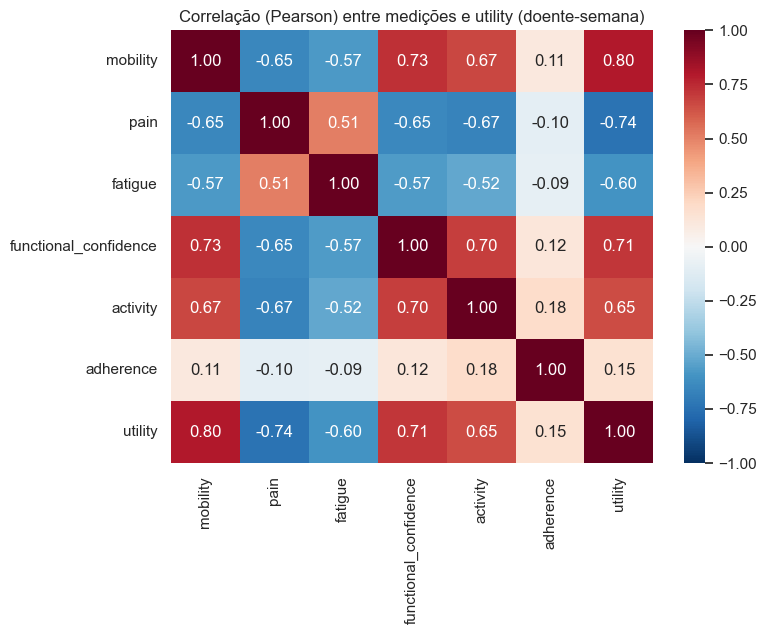

In [25]:
plt.figure(figsize=(8, 6.5))
sns.heatmap(rehab[MEASURES + ["utility"]].corr(), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Correlação (Pearson) entre medições e utility (doente-semana)"); plt.tight_layout(); plt.show()

**Análise de Componentes Principais (PCA) para visualização dos estados latentes**
Inspirado pela redução de dimensionalidade no projeto ECAC, aplicamos PCA para verificar se os três estados de recuperação (Limited, Recovering, Functional) são separáveis no espaço de características latentes, o que servirá de base para os Mixture Models no Milestone M1.

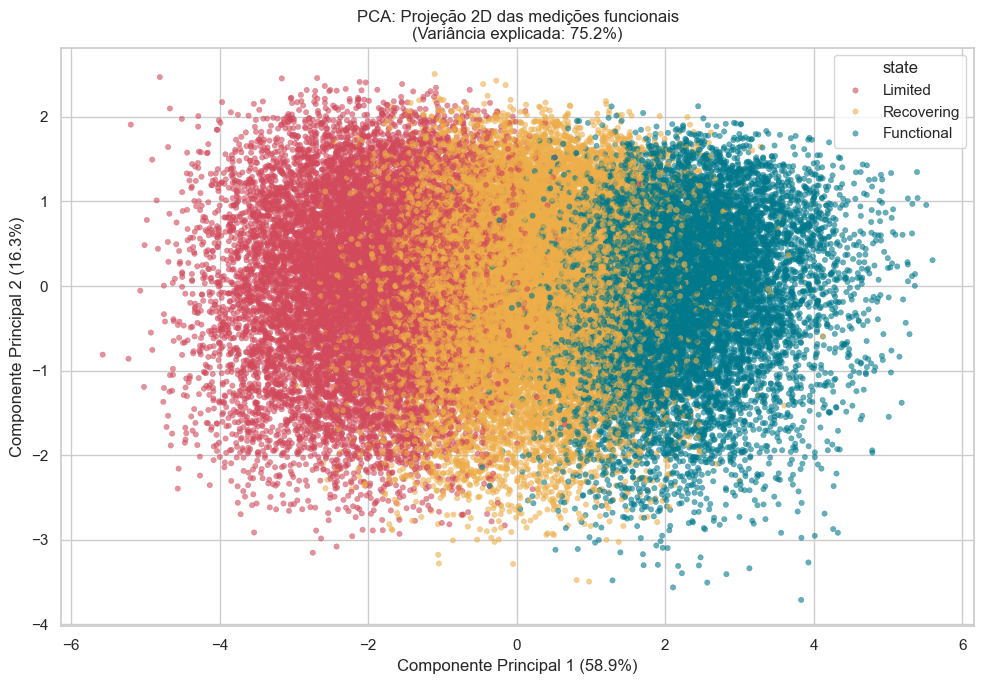

Interpretação: A PCA mostra que a Componente 1 separa razoavelmente os três estados, confirmando que os estados latentes são observáveis a partir de uma combinação linear destas métricas, embora com sobreposição.


In [26]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Preparar os dados (apenas variáveis contínuas que variam no tempo)
X = rehab[MEASURES].dropna()
y = rehab.loc[X.index, 'state']

# Normalizar os dados (Z-score standardisation como no ECAC)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA (2 componentes para visualização 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, hue_order=STATE_ORDER, palette=STATE_PAL, s=15, alpha=0.6, edgecolor=None)
plt.title(f'PCA: Projeção 2D das medições funcionais\n(Variância explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%)')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.tight_layout()
plt.show()

print('Interpretação: A PCA mostra que a Componente 1 separa razoavelmente os três estados, confirmando que os estados latentes são observáveis a partir de uma combinação linear destas métricas, embora com sobreposição.')

As medições estão fortemente **correlacionadas** entre si (p.ex. mobility–functional_confidence ≈ 0.73, mobility–pain ≈ −0.65), o que é compatível com uma causa comum — o estado latente de recuperação. Para o GMM (M1) isto sugere usar matrizes de covariância completas (ou considerar redução de dimensionalidade); para as Bayesian networks sugere uma estrutura em que o estado é pai das várias medições. `adherence` é quase independente das restantes.

## Task 5 — Intervenções de reabilitação e resultados

,n,%
intervention,,
Rest/Recovery,6734,16.03
Light Exercise,13049,31.07
Standard Therapy,15205,36.20
Intensive Therapy,7012,16.70


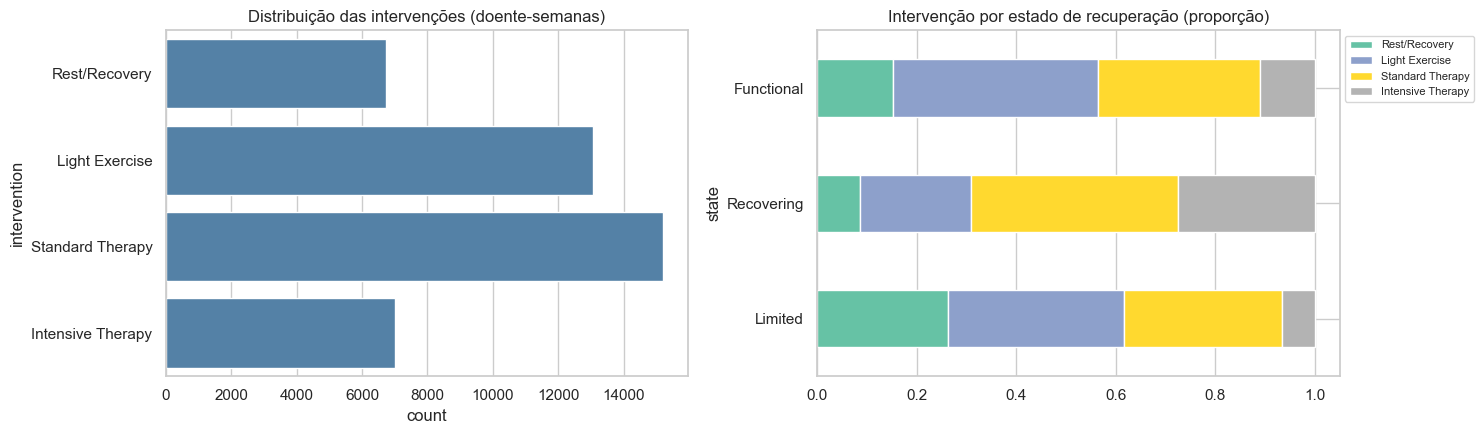

P(intervenção | estado) em %:


intervention,Rest/Recovery,Light Exercise,Standard Therapy,Intensive Therapy
state,,,,
Limited,26.2,35.5,31.8,6.6
Recovering,8.7,22.1,41.6,27.6
Functional,15.3,41.1,32.6,11.0


P(estado | intervenção) em %:


state,Limited,Recovering,Functional
intervention,,,
Rest/Recovery,53.8,23.3,22.9
Light Exercise,37.6,30.7,31.7
Standard Therapy,28.9,49.5,21.6
Intensive Therapy,12.9,71.2,15.9


Qui-quadrado = 4966.8, dof = 6, p = 0.00e+00, V de Cramér = 0.243


In [27]:
iv = rehab["intervention"].value_counts().reindex(INTERV_ORDER)
display(pd.DataFrame({"n": iv, "%": (100 * iv / len(rehab)).round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.countplot(y="intervention", data=rehab, order=INTERV_ORDER, ax=axes[0], color="steelblue")
axes[0].set_title("Distribuição das intervenções (doente-semanas)")
ct = pd.crosstab(rehab["state"], rehab["intervention"], normalize="index").reindex(index=STATE_ORDER, columns=INTERV_ORDER)
ct.plot(kind="barh", stacked=True, ax=axes[1], colormap="Set2")
axes[1].set_title("Intervenção por estado de recuperação (proporção)"); axes[1].legend(bbox_to_anchor=(1, 1), fontsize=8)
plt.tight_layout(); plt.show()

print("P(intervenção | estado) em %:")
display((100 * ct).round(1))
print("P(estado | intervenção) em %:")
display((100 * pd.crosstab(rehab["intervention"], rehab["state"], normalize="index").reindex(index=INTERV_ORDER, columns=STATE_ORDER)).round(1))
chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab(rehab["state"], rehab["intervention"]))
n = len(rehab); cramer = np.sqrt(chi2 / (n * (min(3, 4) - 1)))
print(f"Qui-quadrado = {chi2:.1f}, dof = {dof}, p = {p:.2e}, V de Cramér = {cramer:.3f}")

**Distribuição das intervenções:** Standard Therapy é a mais frequente (≈ 36%), seguida de Light Exercise (≈ 31%), Intensive Therapy (≈ 17%) e Rest/Recovery (≈ 16%).

**Intervenções por estado:** a escolha da intervenção depende claramente do estado (associação moderada, V de Cramér acima):
- Em **Limited** usa-se mais Rest/Recovery (≈ 26%) e Light Exercise (≈ 36%) e muito pouco Intensive Therapy (≈ 7%).
- Em **Recovering** a terapia é mais intensa: Standard (≈ 42%) e Intensive Therapy (≈ 28%) dominam, e Rest/Recovery é raro (≈ 9%).
- Em **Functional** predominam Light Exercise (≈ 41%) e Standard Therapy (≈ 33%) — manutenção.

Ou seja, as intervenções **não foram atribuídas aleatoriamente**: seguem uma política que reage ao estado do doente (mais repouso quando limitado, mais intensidade na fase de recuperação ativa).

count    42000.00
mean         2.17
std         10.23
min        -33.70
25%         -5.10
50%          2.00
75%          9.40
max         40.60
Name: utility, dtype: float64

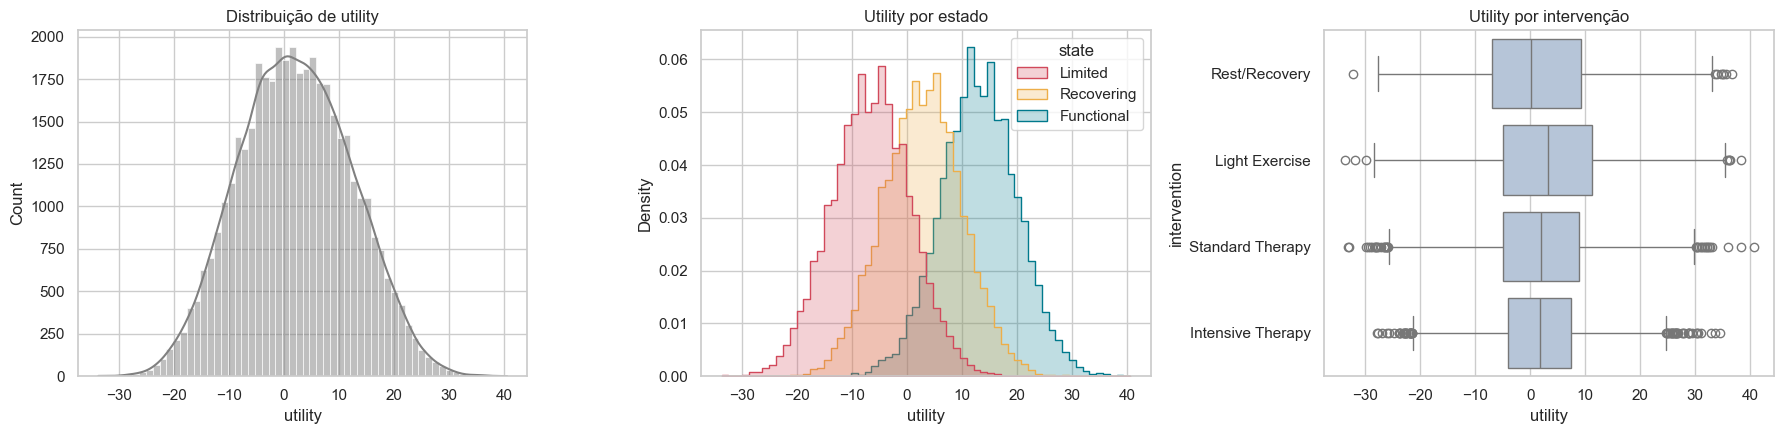

,mean,median,std
state,,,
Limited,-6.62,-6.5,7.15
Recovering,2.79,2.8,7.14
Functional,13.12,13.1,6.92


,mean,median,std
intervention,,,
Rest/Recovery,1.13,0.1,10.95
Light Exercise,3.20,3.2,10.90
Standard Therapy,1.93,2.0,9.93
Intensive Therapy,1.78,1.7,8.60


In [28]:
display(rehab["utility"].describe().round(2))
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
sns.histplot(rehab["utility"], bins=60, kde=True, ax=axes[0], color="gray"); axes[0].set_title("Distribuição de utility")
sns.histplot(data=rehab, x="utility", hue="state", hue_order=STATE_ORDER, palette=STATE_PAL, bins=60, element="step", stat="density", common_norm=False, ax=axes[1])
axes[1].set_title("Utility por estado")
sns.boxplot(x="utility", y="intervention", data=rehab, order=INTERV_ORDER, ax=axes[2], color="lightsteelblue")
axes[2].set_title("Utility por intervenção")
plt.tight_layout(); plt.show()
display(rehab.groupby("state")["utility"].agg(["mean", "median", "std"]).reindex(STATE_ORDER).round(2))
display(rehab.groupby("intervention")["utility"].agg(["mean", "median", "std"]).reindex(INTERV_ORDER).round(2))

**Distribuição de utility:** média ≈ 2.2, dp ≈ 10.2, entre ≈ −34 e ≈ 41; aproximadamente unimodal mas larga, com valores negativos e positivos. Esta forma resulta da mistura de três distribuições condicionais bem separadas por estado: **Limited** (média ≈ −6.6), **Recovering** (≈ +2.8) e **Functional** (≈ +13.1). O estado de recuperação é, de longe, o principal determinante da utility semanal — o que é esperado, dado que a utility incorpora o estado funcional e os sintomas.

**Por intervenção (marginalmente)**, as diferenças são pequenas (médias entre ≈ 1.1 e ≈ 3.2) e difíceis de interpretar, porque cada intervenção é aplicada a uma mistura diferente de estados.

Utility média por estado × intervenção:


intervention,Rest/Recovery,Light Exercise,Standard Therapy,Intensive Therapy
state,,,,
Limited,-5.99,-6.30,-7.32,-7.49
Recovering,4.42,3.90,2.77,1.40
Functional,14.47,13.76,12.39,11.02


Nº de observações por célula:


intervention,Rest/Recovery,Light Exercise,Standard Therapy,Intensive Therapy
state,,,,
Limited,3622,4904,4395,908
Recovering,1568,4004,7525,4991
Functional,1544,4141,3285,1113


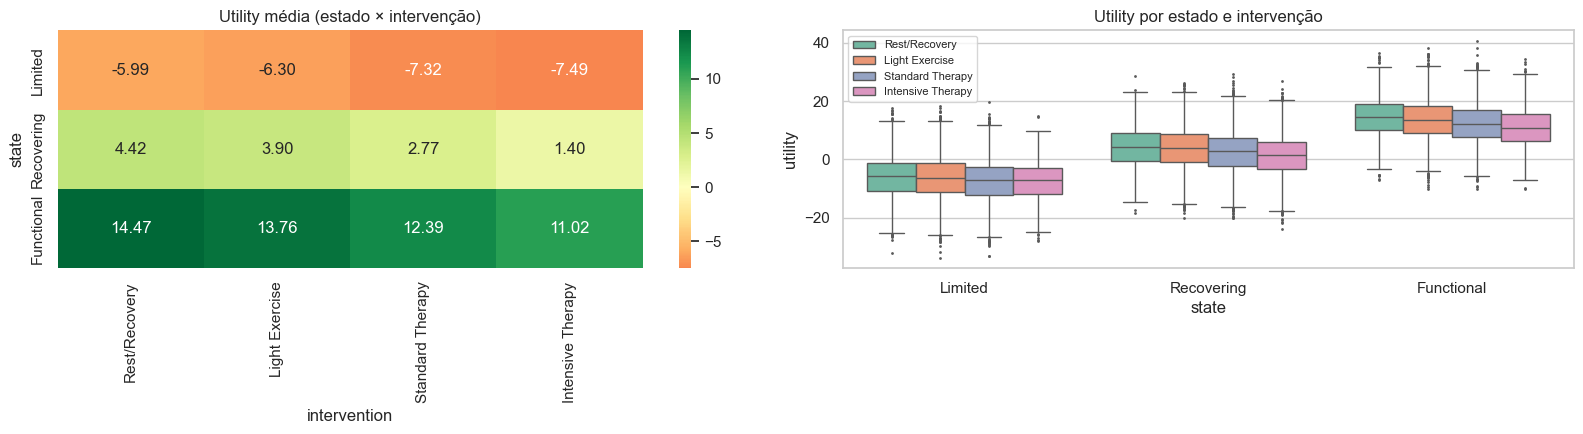

In [29]:
pt = rehab.pivot_table(index="state", columns="intervention", values="utility", aggfunc="mean").reindex(index=STATE_ORDER, columns=INTERV_ORDER)
cnt = rehab.pivot_table(index="state", columns="intervention", values="utility", aggfunc="count").reindex(index=STATE_ORDER, columns=INTERV_ORDER)
print("Utility média por estado × intervenção:"); display(pt.round(2))
print("Nº de observações por célula:"); display(cnt)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
sns.heatmap(pt, annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=axes[0]); axes[0].set_title("Utility média (estado × intervenção)")
sns.boxplot(x="state", y="utility", hue="intervention", data=rehab, order=STATE_ORDER, hue_order=INTERV_ORDER, ax=axes[1], palette="Set2", fliersize=1)
axes[1].set_title("Utility por estado e intervenção"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [30]:
# Olhar para além da utility imediata: variação de estado na semana seguinte, por estado atual e intervenção
rs["intervention"] = rehab.sort_values(["patient_id", "week"])["intervention"].values
rs["next_s"] = rs.groupby("patient_id")["s"].shift(-1)
rs["next_utility"] = rs.groupby("patient_id")["utility"].shift(-1)
nxt = rs.dropna(subset=["next_s"])
prog = nxt.assign(improved=(nxt["next_s"] > nxt["s"]).astype(float)).pivot_table(
    index="state", columns="intervention", values="improved", aggfunc="mean").reindex(index=STATE_ORDER[:2], columns=INTERV_ORDER)
print("P(estado melhora na semana seguinte | estado atual, intervenção) — %:"); display((100 * prog).round(1))
nu = nxt.pivot_table(index="state", columns="intervention", values="next_utility", aggfunc="mean").reindex(index=STATE_ORDER, columns=INTERV_ORDER)
print("Utility média na semana SEGUINTE | estado atual, intervenção:"); display(nu.round(2))

P(estado melhora na semana seguinte | estado atual, intervenção) — %:


intervention,Rest/Recovery,Light Exercise,Standard Therapy,Intensive Therapy
state,,,,
Limited,9.6,14.0,18.4,15.8
Recovering,5.2,8.4,12.4,16.5


Utility média na semana SEGUINTE | estado atual, intervenção:


intervention,Rest/Recovery,Light Exercise,Standard Therapy,Intensive Therapy
state,,,,
Limited,-6.58,-6.00,-5.56,-5.11
Recovering,3.13,3.63,4.25,4.73
Functional,13.38,13.84,13.60,13.69


**A utility difere sistematicamente por estado ou intervenção?**
- **Por estado: sim, fortemente** (≈ −6.6 / +2.8 / +13.1).
- **Por intervenção, dentro do mesmo estado:** as diferenças são menores mas consistentes: Rest/Recovery e Light Exercise apresentam a **utility imediata mais alta** em todos os estados, e Intensive/Standard Therapy a mais baixa. Isto é compatível com a descrição da utility, que penaliza o **esforço/carga** associado à intervenção nessa semana.
- Porém, a utility imediata não conta toda a história. Olhando para a semana seguinte, o padrão **inverte-se**: em Limited, a probabilidade de melhorar é ≈ 10% com Rest/Recovery contra ≈ 18% com Standard Therapy; em Recovering, ≈ 5% com Rest/Recovery contra ≈ 17% com Intensive Therapy. Também a utility na semana seguinte é maior após intervenções mais intensas (p.ex. Recovering: 3.1 após Rest vs. 4.7 após Intensive). Ou seja, as intervenções que "custam" mais no imediato parecem estar associadas a maior progressão — é precisamente o **compromisso curto vs. longo prazo** que será explorado no M6 (reinforcement learning).

**Podemos concluir, só com esta EDA, qual a melhor intervenção para cada estado? Não.** Razões:
1. **Confundimento por indicação:** a intervenção não foi atribuída aleatoriamente, depende do estado (e provavelmente de outras características do doente, como gravidade, dor ou risco). Diferenças de utility entre intervenções podem refletir *quem* recebe cada intervenção e não o efeito da intervenção. Mesmo condicionando no estado (3 níveis grosseiros), permanece heterogeneidade dentro de cada estado (p.ex. um doente "Limited" com mobilidade 20 vs. 45).
2. **Horizonte temporal:** a utility é medida semana a semana; uma intervenção que reduz a utility imediata (maior carga) pode acelerar a recuperação e aumentar a utility acumulada. A escolha ótima deve maximizar o **retorno a longo prazo**, o que exige modelar as transições de estado (decisões sequenciais — M6).
3. **Associação ≠ causalidade** e o próprio enunciado avisa que o dataset é **sintético** e não tem validade clínica/causal.
4. As observações doente-semana **não são independentes** (medições repetidas do mesmo doente), pelo que tratar as linhas como independentes subestima a incerteza.

Uma comparação justa exigiria, por exemplo, ajuste para confundidores, modelos causais/contrafactuais, ou um modelo do ambiente e aprendizagem de políticas que otimizem a utility cumulativa.

## Task 6 — Verificação da qualidade dos dados

In [31]:
print("Valores em falta — patients.csv:"); print(patients.isna().sum().to_string())
print("\nValores em falta — rehabilitation.csv:"); print(rehab.isna().sum().to_string())
print(f"\nLinhas completamente duplicadas: patients = {patients.duplicated().sum()}, rehab = {rehab.duplicated().sum()}")
print(f"patient_id duplicado em patients.csv: {patients['patient_id'].duplicated().sum()}")
print(f"Pares (patient_id, week) duplicados em rehabilitation.csv: {rehab.duplicated(['patient_id', 'week']).sum()}")
print(f"IDs em rehab sem baseline: {len(set(rehab.patient_id) - set(patients.patient_id))}; "
      f"IDs em patients sem dados semanais: {len(set(patients.patient_id) - set(rehab.patient_id))}")

Valores em falta — patients.csv:
patient_id           0
age                  0
sex                  0
bmi                  0
injury_severity      0
baseline_mobility    0
baseline_pain        0
comorbidity_score    0
physical_activity    0
risk_score           0

Valores em falta — rehabilitation.csv:
patient_id               0
week                     0
state                    0
mobility                 0
pain                     0
fatigue                  0
functional_confidence    0
activity                 0
adherence                0
intervention             0
utility                  0

Linhas completamente duplicadas: patients = 0, rehab = 0
patient_id duplicado em patients.csv: 0
Pares (patient_id, week) duplicados em rehabilitation.csv: 0
IDs em rehab sem baseline: 0; IDs em patients sem dados semanais: 0


In [32]:
# Consistência de valores com a descrição do enunciado
expected_ranges = {
    ("patients", "baseline_mobility"): (0, 100), ("patients", "baseline_pain"): (0, 10),
    ("patients", "comorbidity_score"): (0, 5), ("patients", "risk_score"): (0, 100),
    ("patients", "age"): (0, 120), ("patients", "bmi"): (10, 70),
    ("rehab", "week"): (0, 13), ("rehab", "mobility"): (0, 100), ("rehab", "pain"): (0, 10),
    ("rehab", "fatigue"): (0, 10), ("rehab", "functional_confidence"): (0, 100),
    ("rehab", "activity"): (0, 110), ("rehab", "adherence"): (0, 100),
}
dfs = {"patients": patients, "rehab": rehab}
rows = []
for (f, c), (lo, hi) in expected_ranges.items():
    s = dfs[f][c]
    rows.append({"ficheiro": f, "variável": c, "esperado": f"[{lo}, {hi}]", "min": s.min(), "max": s.max(),
                 "fora do intervalo": int(((s < lo) | (s > hi)).sum()),
                 "= mínimo esperado": int((s == lo).sum()), "= máximo esperado": int((s == hi).sum())})
display(pd.DataFrame(rows))

expected_cats = {("patients", "sex"): {"Male", "Female"}, ("patients", "injury_severity"): set(SEV_ORDER),
                 ("patients", "physical_activity"): set(PA_ORDER), ("rehab", "state"): set(STATE_ORDER),
                 ("rehab", "intervention"): set(INTERV_ORDER)}
for (f, c), exp in expected_cats.items():
    obs = set(dfs[f][c].unique())
    print(f"{c:18s} categorias observadas = {sorted(obs)} | inesperadas: {obs - exp or 'nenhuma'}")
print("comorbidity_score é inteiro:", (patients["comorbidity_score"] % 1 == 0).all())

,ficheiro,variável,esperado,min,max,fora do intervalo,= mínimo esperado,= máximo esperado
0,patients,baseline_mobility,"[0, 100]",5.0,82.6,0,0,0
1,patients,baseline_pain,"[0, 10]",2.1,10.0,0,0,36
2,patients,comorbidity_score,"[0, 5]",0.0,5.0,0,935,20
3,patients,risk_score,"[0, 100]",4.2,94.5,0,0,0
4,patients,age,"[0, 120]",18.0,85.0,0,0,0
5,patients,bmi,"[10, 70]",17.0,42.0,0,0,0
6,rehab,week,"[0, 13]",0.0,13.0,0,3000,3000
7,rehab,mobility,"[0, 100]",3.2,100.0,0,0,21
8,rehab,pain,"[0, 10]",0.0,10.0,0,6,121
9,rehab,fatigue,"[0, 10]",0.0,10.0,0,6,35


sex                categorias observadas = ['Female', 'Male'] | inesperadas: nenhuma
injury_severity    categorias observadas = ['Mild', 'Moderate', 'Severe'] | inesperadas: nenhuma
physical_activity  categorias observadas = ['High', 'Low', 'Moderate'] | inesperadas: nenhuma
state              categorias observadas = ['Functional', 'Limited', 'Recovering'] | inesperadas: nenhuma
intervention       categorias observadas = ['Intensive Therapy', 'Light Exercise', 'Rest/Recovery', 'Standard Therapy'] | inesperadas: nenhuma
comorbidity_score é inteiro: True


In [33]:
# Outliers (regra IQR 1.5) — apenas para sinalizar, não para remover
def iqr_outliers(s):
    q1, q3 = s.quantile([.25, .75]); i = q3 - q1
    return int(((s < q1 - 1.5 * i) | (s > q3 + 1.5 * i)).sum())
out = pd.Series({c: iqr_outliers(patients[c]) for c in num_static} | {c: iqr_outliers(rehab[c]) for c in MEASURES + ["utility"]})
display(out.to_frame("nº outliers (IQR)").T)

# Consistência baseline vs. semana 0
w0 = rehab[rehab["week"] == 0].merge(patients, on="patient_id")
for a, b in [("mobility", "baseline_mobility"), ("pain", "baseline_pain")]:
    diff = w0[a] - w0[b]
    print(f"{a} (semana 0) vs {b}: correlação = {w0[[a, b]].corr().iloc[0, 1]:.3f}, "
          f"diferença média = {diff.mean():.2f}, dp = {diff.std():.2f}, |dif| máx = {diff.abs().max():.1f}")

# Desequilíbrio de classes e células esparsas
print("\nNº de doentes que começam em Functional:", int((rehab.query("week == 0")["state"] == "Functional").sum()))
print("Menor célula estado × intervenção:", int(cnt.values.min()))

,age,bmi,comorbidity_score,baseline_mobility,baseline_pain,risk_score,mobility,pain,fatigue,functional_confidence,activity,adherence,utility
nº outliers (IQR),0,9,0,11,7,0,51,52,157,52,44,68,74


mobility (semana 0) vs baseline_mobility: correlação = 0.888, diferença média = 0.62, dp = 5.69, |dif| máx = 23.0
pain (semana 0) vs baseline_pain: correlação = 0.840, diferença média = -0.09, dp = 0.79, |dif| máx = 2.7

Nº de doentes que começam em Functional: 3
Menor célula estado × intervenção: 908


**Deteção de Outliers Multivariada (Z-Score)**
De forma semelhante à metodologia explorada no projeto ECAC, complementamos o método IQR com a análise Z-score para as medições. Como planeamos usar Gaussian Mixture Models (M1), que são muito sensíveis a outliers, é útil avaliar se existem valores extremos multivariados.

Nº total de outliers pelo método Z-score (k=3.0): 203 (0.48% dos dados)


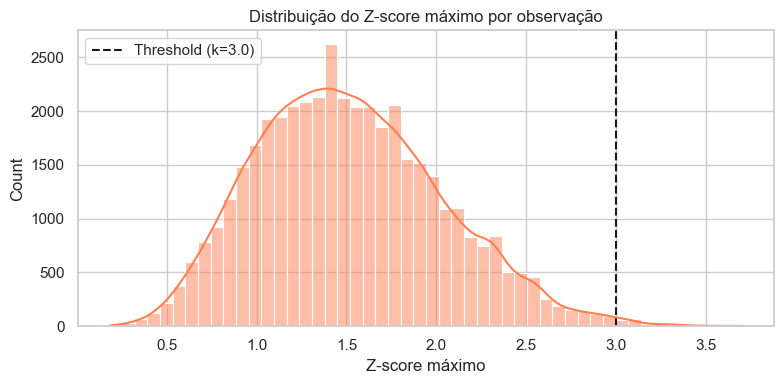

Embora existam alguns outliers, a sua proporção é pequena e podem representar estados clínicos válidos e extremos (não ruído do sensor). Por isso, optamos por não os remover, mas tomamos nota para os modelos probabilísticos.


In [34]:
import numpy as np

# Z-score threshold (k=3, como no ECAC)
threshold_k = 3.0
z_scores = np.abs(stats.zscore(rehab[MEASURES].dropna()))

# Identificar outliers (pelo menos uma dimensão > k)
outlier_mask = (z_scores > threshold_k).any(axis=1)
n_z_outliers = outlier_mask.sum()

print(f'Nº total de outliers pelo método Z-score (k={threshold_k}): {n_z_outliers} ({(n_z_outliers/len(rehab))*100:.2f}% dos dados)')

# Visualizar a distribuição dos Z-scores máximos por observação
plt.figure(figsize=(8, 4))
sns.histplot(z_scores.max(axis=1), bins=50, color='coral', kde=True)
plt.axvline(threshold_k, color='k', linestyle='--', label=f'Threshold (k={threshold_k})')
plt.title('Distribuição do Z-score máximo por observação')
plt.xlabel('Z-score máximo')
plt.legend()
plt.tight_layout()
plt.show()

print('Embora existam alguns outliers, a sua proporção é pequena e podem representar estados clínicos válidos e extremos (não ruído do sensor). Por isso, optamos por não os remover, mas tomamos nota para os modelos probabilísticos.')

**Resultados da verificação de qualidade:**
- **Valores em falta:** não existem, em nenhum dos ficheiros.
- **Duplicados:** não há linhas duplicadas, nem `patient_id` repetidos em `patients.csv`, nem pares (`patient_id`, `week`) repetidos em `rehabilitation.csv`. Todos os doentes existem em ambos os ficheiros e têm as 14 semanas.
- **Intervalos e categorias:** todos os valores estão dentro dos intervalos descritos no enunciado e todas as categorias são as esperadas (sem erros de grafia/maiúsculas). `comorbidity_score` é inteiro.

**Outros potenciais problemas a considerar antes de aplicar ML:**
1. **Efeitos de chão/teto (*clipping*):** várias variáveis acumulam valores nos limites da escala (p.ex. `activity = 0` em ~240 doente-semanas, `pain = 10` em ~120). As distribuições são truncadas e não Gaussianas junto aos limites, o que viola parcialmente as hipóteses de um GMM Gaussiano.
2. **Escalas diferentes:** as variáveis estão em escalas muito diferentes (0–10, 0–100, 0–110), pelo que é necessário **normalizar/estandardizar** antes de métodos baseados em distâncias ou covariâncias (M1).
3. **Não independência das observações:** as 42 000 linhas são 14 medições repetidas de 3000 doentes. Tratá-las como independentes (como pedido no M0/M1) ignora a correlação intra-doente e a ordem temporal; na validação de modelos, a divisão treino/teste deve ser feita **por doente** para evitar *data leakage*.
4. **Baseline vs. semana 0:** `baseline_mobility`/`baseline_pain` e as medições da semana 0 estão fortemente correlacionadas mas não são iguais (diferenças até ~20 pontos na mobilidade) — são medições ruidosas do mesmo constructo, o que ilustra o **ruído de medição**.
5. **Desequilíbrio de classes e células esparsas:** o estado Functional é menos frequente e quase não existe nas primeiras semanas; algumas combinações estado × intervenção têm relativamente poucas observações, o que tornará mais incerta a estimação das CPTs (M2–M4) e das políticas (M6).
6. **Confundimento por indicação** das intervenções (Task 5) — relevante para qualquer interpretação causal e para aprender políticas a partir de dados observacionais.
7. **Redundância/colinearidade:** `risk_score` é em grande parte uma combinação das restantes variáveis de baseline, e as medições semanais estão fortemente correlacionadas entre si.
8. **Variáveis contínuas vs. discretas:** para Bayesian networks discretas (M2–M4) será preciso discretizar as variáveis contínuas; a escolha dos pontos de corte (p.ex. quantis ou limiares clínicos) influenciará os resultados.
9. **Precisão:** os valores estão arredondados a 1 casa decimal, pelo que existem muitos empates (irrelevante para a maioria dos métodos, mas a ter em conta p.ex. em testes baseados em ranks).
10. **`state` é a variável latente verdadeira:** está disponível apenas porque os dados são sintéticos. Não deve ser usada como *feature* em modelos que pretendem inferi-la (M1, M5), apenas para avaliação/interpretação.

## Conclusões e hipóteses para os próximos milestones

1. **Dados limpos e balanceados:** 3000 doentes × 14 semanas, sem valores em falta, duplicados ou valores fora do intervalo — o pré-processamento necessário resume-se sobretudo a normalização, (eventual) discretização e tratamento dos efeitos de chão/teto.
2. **Heterogeneidade na baseline:** a gravidade da lesão, a mobilidade e dor iniciais, a idade e as comorbilidades estão associadas ao `risk_score` e condicionam a velocidade de recuperação. *Hipótese (M2):* estas variáveis são pais (diretos ou indiretos) do estado de recuperação numa Bayesian network.
3. **Estado latente observado com ruído:** as medições diferem de forma monótona entre estados mas sobrepõem-se bastante. *Hipótese (M1):* um GMM sobre as medições deverá recuperar grupos ordenados segundo um eixo "nível funcional" (mobilidade/confiança/atividade altas vs. dor/fadiga altas), com confusão sobretudo entre estados adjacentes; `adherence` contribuirá pouco para separar estados.
4. **Dinâmica ordenada e persistente:** Limited → Recovering → Functional, com estados muito persistentes, transições quase só entre estados adjacentes e alguns retrocessos. *Hipótese (M5):* um HMM de 3 estados com matriz de transição quase triangular superior deverá ajustar-se bem.
5. **Intervenções e utility:** a utility depende sobretudo do estado; intervenções mais intensas têm utility imediata ligeiramente inferior. Como as intervenções são escolhidas em função do estado, a EDA não permite concluir qual a melhor intervenção. *Hipótese (M6):* a política ótima terá de equilibrar a carga imediata da terapia com o seu efeito nas transições de estado futuras.